Diante Calhoun
CIS 732
Next-Day Stock Price Prediction Accuracy using 30-day Trends across Technology, Healthcare, and Consumer Staples

In [6]:
# Cell 1 — Environment Check
import importlib

required = [
    "pandas", "numpy", "matplotlib", "seaborn",
    "sklearn", "tensorflow", "yfinance", "kaggle"
]

for lib in required:
    found = importlib.util.find_spec(lib)
    print(f"{'✓' if found else '✗'} {lib}")

✓ pandas
✓ numpy
✓ matplotlib
✓ seaborn
✓ sklearn
✓ tensorflow
✓ yfinance
✓ kaggle


In [4]:
pip install tensorflow

   ---------------------------------------- 0.0/350.8 MB ? eta -:--:--
   ---------------------------------------- 0.2/350.8 MB 5.9 MB/s eta 0:00:59
   ---------------------------------------- 1.0/350.8 MB 10.8 MB/s eta 0:00:33
   ---------------------------------------- 3.0/350.8 MB 24.2 MB/s eta 0:00:15
    --------------------------------------- 4.8/350.8 MB 28.1 MB/s eta 0:00:13
    --------------------------------------- 7.1/350.8 MB 32.3 MB/s eta 0:00:11
   - -------------------------------------- 10.8/350.8 MB 54.7 MB/s eta 0:00:07
   - -------------------------------------- 14.9/350.8 MB 73.1 MB/s eta 0:00:05
   -- ------------------------------------- 18.9/350.8 MB 93.9 MB/s eta 0:00:04
   -- ------------------------------------- 22.9/350.8 MB 93.9 MB/s eta 0:00:04
   -- ------------------------------------- 25.0/350.8 MB 72.6 MB/s eta 0:00:05
   --- ------------------------------------ 28.7/350.8 MB 72.6 MB/s eta 0:00:05
   --- ------------------------------------ 30.8/350.8 

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
googleapis-common-protos 1.69.0 requires protobuf!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0.dev0,>=3.20.2, but you have protobuf 7.34.1 which is incompatible.
google-api-core 2.24.1 requires protobuf!=3.20.0,!=3.20.1,!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0.dev0,>=3.19.5, but you have protobuf 7.34.1 which is incompatible.
proto-plus 1.26.0 requires protobuf<6.0.0dev,>=3.19.0, but you have protobuf 7.34.1 which is incompatible.
streamlit 1.30.0 requires protobuf<5,>=3.20, but you have protobuf 7.34.1 which is incompatible.


  Using cached tensorflow-2.21.0-cp311-cp311-win_amd64.whl.metadata (4.5 kB)
Using cached tensorflow-2.21.0-cp311-cp311-win_amd64.whl (350.8 MB)
Note: you may need to restart the kernel to use updated packages.


In [5]:
pip install kaggle

In [11]:
# Pull the Kaggle dataset
import kaggle
import os

# download the dataset
kaggle.api.authenticate()

dataset = "andrewmvd/sp-500-stocks"
download_path = "./data"

os.makedirs(download_path, exist_ok=True)
kaggle.api.dataset_download_files(dataset, path=download_path, unzip=True)

print("Files downloaded:")
for f in os.listdir(download_path):
    print(f" - {f}")

Dataset URL: https://www.kaggle.com/datasets/andrewmvd/sp-500-stocks
Files downloaded:
 - sp500_companies.csv
 - sp500_index.csv
 - sp500_stocks.csv


In [12]:
# quick review of the data
import pandas as pd

df = pd.read_csv("./data/sp500_stocks.csv")

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nDate range:", df["Date"].min(), "→", df["Date"].max())
print("\nSample:")
df.head()

Shape: (1891536, 8)

Columns: ['Date', 'Symbol', 'Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume']

Date range: 2010-01-04 → 2024-12-20

Sample:


,Date,Symbol,Adj Close,Close,High,Low,Open,Volume
0,2010-01-04,MMM,NaN,NaN,NaN,NaN,NaN,NaN
1,2010-01-05,MMM,NaN,NaN,NaN,NaN,NaN,NaN
2,2010-01-06,MMM,NaN,NaN,NaN,NaN,NaN,NaN
3,2010-01-07,MMM,NaN,NaN,NaN,NaN,NaN,NaN
4,2010-01-08,MMM,NaN,NaN,NaN,NaN,NaN,NaN


In [14]:
# Filter for our 3 target stocks
target_stocks = ["ORCL", "JNJ", "PEP"]
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values(["Symbol", "Date"]).reset_index(drop=True)

stock_data = {stock: df[df["Symbol"] == stock] for stock in target_stocks}
for stock, data in stock_data.items():
    print(f"\n{stock}: {len(data)} rows | {data['Date'].min().date()} → {data['Date'].max().date()}")
    print(data.head())


ORCL: 3768 rows | 2010-01-04 → 2024-12-20
              Date Symbol  Adj Close      Close       High        Low  \
1333872 2010-01-04   ORCL  20.269571  24.850000  25.190001  24.660000   
1333873 2010-01-05   ORCL  20.245104  24.820000  24.850000  24.350000   
1333874 2010-01-06   ORCL  19.951458  24.459999  24.920000  24.379999   
1333875 2010-01-07   ORCL  19.886198  24.379999  24.610001  24.080000   
1333876 2010-01-08   ORCL  20.130903  24.680000  24.750000  24.250000   

              Open      Volume  
1333872  24.660000  26795000.0  
1333873  24.719999  28669900.0  
1333874  24.770000  24560700.0  
1333875  24.459999  30469700.0  
1333876  24.280001  23542400.0  

JNJ: 3768 rows | 2010-01-04 → 2024-12-20
             Date Symbol  Adj Close  Close  High  Low  Open  Volume
975912 2010-01-04    JNJ        NaN    NaN   NaN  NaN   NaN     NaN
975913 2010-01-05    JNJ        NaN    NaN   NaN  NaN   NaN     NaN
975914 2010-01-06    JNJ        NaN    NaN   NaN  NaN   NaN     NaN
975915

In [17]:
stock_data = {stock: df[df["Symbol"] == stock] for stock in target_stocks}
for stock, data in stock_data.items():
    print(f"\n{stock}: {len(data)} rows | {data['Date'].min().date()} → {data['Date'].max().date()}")
    print(data.tail())


ORCL: 3768 rows | 2010-01-04 → 2024-12-20
              Date Symbol   Adj Close       Close        High         Low  \
1337635 2024-12-16   ORCL  171.229996  171.229996  174.270004  170.929993   
1337636 2024-12-17   ORCL  169.710007  169.710007  172.990005  169.270004   
1337637 2024-12-18   ORCL  165.410004  165.410004  171.229996  165.360001   
1337638 2024-12-19   ORCL  168.789993  168.789993  171.000000  167.399994   
1337639 2024-12-20   ORCL  169.660004  169.660004  171.259995  165.630005   

               Open      Volume  
1337635  173.839996   9572000.0  
1337636  170.750000   8940200.0  
1337637  169.410004   8817900.0  
1337638  167.550003   8386400.0  
1337639  167.729996  13776300.0  

JNJ: 3768 rows | 2010-01-04 → 2024-12-20
             Date Symbol  Adj Close  Close  High  Low  Open  Volume
979675 2024-12-16    JNJ        NaN    NaN   NaN  NaN   NaN     NaN
979676 2024-12-17    JNJ        NaN    NaN   NaN  NaN   NaN     NaN
979677 2024-12-18    JNJ        NaN    NaN  

In [16]:
# Find JNJ dates that have values
jnj_data = stock_data["JNJ"]
print(f"JNJ dates with values: {len(jnj_data)}")
print("non-null jnj rows:", jnj_data["Adj Close"].notna().sum())
print("null jnj rows:", jnj_data["Adj Close"].isna().sum())
print("\nFirst non-null JNJ rows:")
print(jnj_data[jnj_data["Adj Close"].notna()].head())
print("tail jnj rows: ")
print(jnj_data[jnj_data["Adj Close"].notna()].tail())

JNJ dates with values: 3768
non-null jnj rows: 0
null jnj rows: 3768

First non-null JNJ rows:
Empty DataFrame
Columns: [Date, Symbol, Adj Close, Close, High, Low, Open, Volume]
Index: []
tail jnj rows: 
Empty DataFrame
Columns: [Date, Symbol, Adj Close, Close, High, Low, Open, Volume]
Index: []


Johnson and Johnson does not have any values in the dataset, so I will pivot to another healthcare company.

In [18]:
# let's find some substitutes for JNJ - using GENAI to give me prospective companites that are similar to JNJ
# Check Healthcare ticker availability
healthcare_candidates = ["ABT", "BMY", "MDT", "UNH", "PFE", "LLY", "ABBV", "MRK", "AMGN"]

for ticker in healthcare_candidates:
    subset = df[df["Symbol"] == ticker]
    valid = subset["Adj Close"].notna().sum()
    print(f"{ticker}: {len(subset)} rows | {valid} non-null Adj Close values")

ABT: 3768 rows | 3768 non-null Adj Close values
BMY: 3768 rows | 0 non-null Adj Close values
MDT: 3768 rows | 0 non-null Adj Close values
UNH: 3768 rows | 0 non-null Adj Close values
PFE: 3768 rows | 0 non-null Adj Close values
LLY: 3768 rows | 0 non-null Adj Close values
ABBV: 3768 rows | 3014 non-null Adj Close values
MRK: 3768 rows | 3768 non-null Adj Close values
AMGN: 3768 rows | 0 non-null Adj Close values


My personal preference for this dataset, was to have values from Eli Lilly, since it may not be a complete consumer products winner but it is considered the gold standard for it's sector.
Abbview was considered as it's a stronger pharmaceutical healthcare fit, however, the amount of rows with data is shorter than what is available for Merck & Co.
So I'll adjust to using Merck and Co.

In [19]:
# reupdate as we substitute JNJ with MRK
target_stocks = ["ORCL", "MRK", "PEP"]
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values(["Symbol", "Date"]).reset_index(drop=True)

stock_data = {stock: df[df["Symbol"] == stock] for stock in target_stocks}
for stock, data in stock_data.items():
    print(f"\n{stock}: {len(data)} rows | {data['Date'].min().date()} → {data['Date'].max().date()}")
    print(data.head())


ORCL: 3768 rows | 2010-01-04 → 2024-12-20
              Date Symbol  Adj Close      Close       High        Low  \
1333872 2010-01-04   ORCL  20.269571  24.850000  25.190001  24.660000   
1333873 2010-01-05   ORCL  20.245104  24.820000  24.850000  24.350000   
1333874 2010-01-06   ORCL  19.951458  24.459999  24.920000  24.379999   
1333875 2010-01-07   ORCL  19.886198  24.379999  24.610001  24.080000   
1333876 2010-01-08   ORCL  20.130903  24.680000  24.750000  24.250000   

              Open      Volume  
1333872  24.660000  26795000.0  
1333873  24.719999  28669900.0  
1333874  24.770000  24560700.0  
1333875  24.459999  30469700.0  
1333876  24.280001  23542400.0  

MRK: 3768 rows | 2010-01-04 → 2024-12-20
              Date Symbol  Adj Close      Close       High        Low  \
1201992 2010-01-04    MRK  21.387215  35.314884  35.543892  34.875954   
1201993 2010-01-05    MRK  21.473898  35.458015  35.734734  35.238548   
1201994 2010-01-06    MRK  21.762827  35.935116  36.001907 

In [20]:
# Feature Selection
# using Adjusted close as primary target with the price based features. Intentionally leaving out volume to reduce the noise and focus on price trends.
features = ["Adj Close", "Open", "High", "Low"]
target = "Adj Close"

feature_data = {}
for stock, data in stock_data.items():
    subset = data[["Date"] + features].copy()
    subset = subset.reset_index(drop=True)
    feature_data[stock] = subset
    print(f"\n{stock}: {subset.shape} | Null values:\n{subset[features].isna().sum().sum()}")


ORCL: (3768, 5) | Null values:
0

MRK: (3768, 5) | Null values:
0

PEP: (3768, 5) | Null values:
0


# Train, Validate and Test Split
We're splitting the inormation with a 70/15/15 split chronologically. Remember - the data goes back to 2010 and that's where our training starts

In [23]:
# 70/15/15 Chronological Split

train_ratio = 0.7
val_ratio = 0.15
test_ratio = 0.15

split_data = {}

for stock, data in feature_data.items():
    n = len(data)
    train_end = int(n * train_ratio)
    val_end = train_end + int(n * val_ratio)

    split_data[stock] = {
        "train": data.iloc[:train_end].copy().reset_index(drop=True),
        "val": data.iloc[train_end:val_end].copy().reset_index(drop=True),
        "test": data.iloc[val_end:].copy().reset_index(drop=True)
    }

    for split_name, split_df in split_data[stock].items():
        print(f"{stock} {split_name} split: {len(split_df)} rows | Date range: {split_df['Date'].min().date()} → {split_df['Date'].max().date()}")



ORCL train split: 2637 rows | Date range: 2010-01-04 → 2020-06-24
ORCL val split: 565 rows | Date range: 2020-06-25 → 2022-09-21
ORCL test split: 566 rows | Date range: 2022-09-22 → 2024-12-20
MRK train split: 2637 rows | Date range: 2010-01-04 → 2020-06-24
MRK val split: 565 rows | Date range: 2020-06-25 → 2022-09-21
MRK test split: 566 rows | Date range: 2022-09-22 → 2024-12-20
PEP train split: 2637 rows | Date range: 2010-01-04 → 2020-06-24
PEP val split: 565 rows | Date range: 2020-06-25 → 2022-09-21
PEP test split: 566 rows | Date range: 2022-09-22 → 2024-12-20


In [25]:
# Preprocessing
from sklearn.preprocessing import MinMaxScaler

features = ["Adj Close", "Open", "High", "Low"]

scalers = {}
scaled_data = {}

for stock in target_stocks:
    scaler = MinMaxScaler()

    train = split_data[stock]["train"][features].values
    val = split_data[stock]["val"][features].values
    test = split_data[stock]["test"][features].values

    # only fit on train to prevent data leakage
    train_scaled = scaler.fit_transform(train)
    val_scaled = scaler.transform(val)
    test_scaled = scaler.transform(test)

    scalers[stock] = scaler
    scaled_data[stock] = {
        "train": train_scaled,
        "val": val_scaled,
        "test": test_scaled
    }
    print(f"{stock} - Scaling complete - train min: {train_scaled.min():.4f}, max: {train_scaled.max():.4f}")
    print(f"{stock} - Validation scaled range: {val_scaled.min():.4f} to {val_scaled.max():.4f}")
    print(f"{stock} - Test scaled range: {test_scaled.min():.4f} to {test_scaled.max():.4f}")

ORCL - Scaling complete - train min: 0.0000, max: 1.0000
ORCL - Validation scaled range: 0.8377 to 2.1808
ORCL - Test scaled range: 1.0209 to 4.6456
MRK - Scaling complete - train min: 0.0000, max: 1.0000
MRK - Validation scaled range: 0.6818 to 1.2327
MRK - Test scaled range: 0.9476 to 1.9771
PEP - Scaling complete - train min: 0.0000, max: 1.0000
PEP - Validation scaled range: 0.7954 to 1.4528
PEP - Test scaled range: 1.0427 to 1.6570


# Sliding Window Sequence Functionality

This is a design decision that I've made to attempt specific time series data for supervised learning.
While this is my design, the scaffolding for this logic was written by Claude.ai

In [26]:
import numpy as np

def create_sequences(data, window):
    """
    Transforms scaled time series data into supervised learning sequences.
    
    Parameters:
        data   : np.array of shape (n_rows, n_features)
        window : int — number of lookback days per sequence
    
    Returns:
        X : np.array of shape (n_samples, window, n_features)
        y : np.array of shape (n_samples,) — next day Adj Close (column 0)
    """
    X, y = [], []
    for i in range(len(data) - window):
        X.append(data[i:i + window])
        y.append(data[i + window][0])  # column 0 = Adj Close
    return np.array(X), np.array(y)

In [27]:
# Actual Lookback windows for 10, 30, 60 days
# logic reworked from Claude to be more readable.
lookback_windows = [10, 30, 60]
sequence_data = {}

for stock in target_stocks:
    stock_sequences = {}
    for window in lookback_windows:
        X_train, y_train = create_sequences(scaled_data[stock]["train"], window)
        X_val, y_val = create_sequences(scaled_data[stock]["val"], window)
        X_test, y_test = create_sequences(scaled_data[stock]["test"], window)
        
        stock_sequences[window] = {
            "X_train": X_train, "y_train": y_train,
            "X_val": X_val,     "y_val": y_val,
            "X_test": X_test,   "y_test": y_test
        }
        print(f"{stock} - Window {window} - Train sequences: {len(X_train)}, Val sequences: {len(X_val)}, Test sequences: {len(X_test)}")
    sequence_data[stock] = stock_sequences

ORCL - Window 10 - Train sequences: 2627, Val sequences: 555, Test sequences: 556
ORCL - Window 30 - Train sequences: 2607, Val sequences: 535, Test sequences: 536
ORCL - Window 60 - Train sequences: 2577, Val sequences: 505, Test sequences: 506
MRK - Window 10 - Train sequences: 2627, Val sequences: 555, Test sequences: 556
MRK - Window 30 - Train sequences: 2607, Val sequences: 535, Test sequences: 536
MRK - Window 60 - Train sequences: 2577, Val sequences: 505, Test sequences: 506
PEP - Window 10 - Train sequences: 2627, Val sequences: 555, Test sequences: 556
PEP - Window 30 - Train sequences: 2607, Val sequences: 535, Test sequences: 536
PEP - Window 60 - Train sequences: 2577, Val sequences: 505, Test sequences: 506


# Build Models
1. Naive Baseline
2. Linear Regression
3. Long Short-Term Memory (LSTM)

In [29]:
# Naive Baseline: Predicting next day Adjusted Close as current day Adjusted Close (persistence model)
# As expected, this is our base floor model. Expectation is all other models should outperform this naive approach.

nb_results = {}
for stock in target_stocks:
    nb_results[stock] = {}
    for window in lookback_windows:
        # the last value of each sequence is the current day Adj Close, which we will use as the prediction for the next day
        y_pred = sequence_data[stock][window]["X_test"][:, -1, 0]  # last day in sequence, Adj Close column
        y_true = sequence_data[stock][window]["y_test"]

        nb_results[stock][window] = {
            "y_true": y_true,
            "y_pred": y_pred
        }

        print(f"{stock} - Window {window} - Naive Baseline prepared with {len(y_pred)} predictions")

ORCL - Window 10 - Naive Baseline prepared with 556 predictions
ORCL - Window 30 - Naive Baseline prepared with 536 predictions
ORCL - Window 60 - Naive Baseline prepared with 506 predictions
MRK - Window 10 - Naive Baseline prepared with 556 predictions
MRK - Window 30 - Naive Baseline prepared with 536 predictions
MRK - Window 60 - Naive Baseline prepared with 506 predictions
PEP - Window 10 - Naive Baseline prepared with 556 predictions
PEP - Window 30 - Naive Baseline prepared with 536 predictions
PEP - Window 60 - Naive Baseline prepared with 506 predictions


In [30]:
# NB Evaluation
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

def evaluate_model(y_true, y_pred, stock, model_name, window):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100 # didn't understand the formula AI chose here, so I used the standard MAPE formula in Oreily textbook.

    print(f"{stock} - {model_name} - Window {window} - MAE: {mae:.4f}, RMSE: {rmse:.4f}, MAPE: {mape:.2f}%")

    return {"stock": stock, "model": model_name, "window": window, "MAE": mae, "RMSE": rmse, "MAPE": mape}

In [38]:
# Run evaluation for Naive Baseline
results = []
for stock in target_stocks:
    for window in lookback_windows:
        y_true = nb_results[stock][window]["y_true"]
        y_pred = nb_results[stock][window]["y_pred"]
        result = evaluate_model(y_true, y_pred, stock, "Naive Baseline", window)
        results.append(result)

ORCL - Naive Baseline - Window 10 - MAE: 0.0395, RMSE: 0.0641, MAPE: 1.51%
ORCL - Naive Baseline - Window 30 - MAE: 0.0398, RMSE: 0.0647, MAPE: 1.48%
ORCL - Naive Baseline - Window 60 - MAE: 0.0407, RMSE: 0.0662, MAPE: 1.47%
MRK - Naive Baseline - Window 10 - MAE: 0.0172, RMSE: 0.0245, MAPE: 1.10%
MRK - Naive Baseline - Window 30 - MAE: 0.0172, RMSE: 0.0246, MAPE: 1.08%
MRK - Naive Baseline - Window 60 - MAE: 0.0171, RMSE: 0.0246, MAPE: 1.07%
PEP - Naive Baseline - Window 10 - MAE: 0.0140, RMSE: 0.0189, MAPE: 0.97%
PEP - Naive Baseline - Window 30 - MAE: 0.0136, RMSE: 0.0184, MAPE: 0.94%
PEP - Naive Baseline - Window 60 - MAE: 0.0136, RMSE: 0.0184, MAPE: 0.94%


Unfortunately, my window idea does not appear to have massive dividends. 
I thought the window of accuracy would change based on the window, but the size is barely changing via the Mean Area Percentage error.
Oracle does appear to have the most volatile stock of the options, with Pepsi showing a slow and steady performance.
Reminder, NB is the baseline, so we're curious to see if the window is more impacted for the other models.

# Linear Regression Model

In [39]:
# Linear Regression Model
from sklearn.linear_model import LinearRegression
lr_results = {}

for stock in target_stocks:
    lr_results[stock] = {}
    for window in lookback_windows:
        X_train = sequence_data[stock][window]["X_train"].reshape(len(sequence_data[stock][window]["X_train"]), -1) # flatten the last two dimensions
        y_train = sequence_data[stock][window]["y_train"]
        X_val = sequence_data[stock][window]["X_val"].reshape(len(sequence_data[stock][window]["X_val"]), -1) # flatten the last two dimensions
        y_val = sequence_data[stock][window]["y_val"]
        X_test = sequence_data[stock][window]["X_test"].reshape(len(sequence_data[stock][window]["X_test"]), -1) # flatten the last two dimensions
        y_test = sequence_data[stock][window]["y_test"]

        # Train Linear Regression
        model = LinearRegression()
        model.fit(X_train, y_train)

        # Predict on test set
        y_pred = model.predict(X_test)

        lr_results[stock][window] = {
            "y_true": y_test,
            "y_pred": y_pred
        }

        print(f"{stock} - Window {window} - Linear Regression trained and predictions made with {len(y_pred)} samples")

ORCL - Window 10 - Linear Regression trained and predictions made with 556 samples
ORCL - Window 30 - Linear Regression trained and predictions made with 536 samples
ORCL - Window 60 - Linear Regression trained and predictions made with 506 samples
MRK - Window 10 - Linear Regression trained and predictions made with 556 samples
MRK - Window 30 - Linear Regression trained and predictions made with 536 samples
MRK - Window 60 - Linear Regression trained and predictions made with 506 samples
PEP - Window 10 - Linear Regression trained and predictions made with 556 samples
PEP - Window 30 - Linear Regression trained and predictions made with 536 samples
PEP - Window 60 - Linear Regression trained and predictions made with 506 samples


In [40]:
# Evaluate Linear Regression
for stock in target_stocks:
    for window in lookback_windows:
        y_true = lr_results[stock][window]["y_true"]
        y_pred = lr_results[stock][window]["y_pred"]
        result = evaluate_model(y_true, y_pred, stock, "Linear Regression", window)
        results.append(result)

ORCL - Linear Regression - Window 10 - MAE: 0.0412, RMSE: 0.0665, MAPE: 1.58%
ORCL - Linear Regression - Window 30 - MAE: 0.0423, RMSE: 0.0678, MAPE: 1.57%
ORCL - Linear Regression - Window 60 - MAE: 0.0457, RMSE: 0.0715, MAPE: 1.65%
MRK - Linear Regression - Window 10 - MAE: 0.0184, RMSE: 0.0255, MAPE: 1.18%
MRK - Linear Regression - Window 30 - MAE: 0.0186, RMSE: 0.0259, MAPE: 1.17%
MRK - Linear Regression - Window 60 - MAE: 0.0195, RMSE: 0.0267, MAPE: 1.22%
PEP - Linear Regression - Window 10 - MAE: 0.0155, RMSE: 0.0205, MAPE: 1.07%
PEP - Linear Regression - Window 30 - MAE: 0.0162, RMSE: 0.0212, MAPE: 1.12%
PEP - Linear Regression - Window 60 - MAE: 0.0169, RMSE: 0.0220, MAPE: 1.17%


# LSTM Model

In [48]:
# Build LSTM Model
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

def build_lstm_model(window, n_features):
    model = Sequential()
    model.add(LSTM(64, input_shape=(window, n_features)))
    model.add(Dropout(0.2))
    model.add(Dense(1))  # Predicting next day Adj Close
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001), # 4-19-26 dropping learning rate from .001 to .0005 to .0001. Should see other windows improve more than 10 day window.
        loss='mse')
    return model

In [49]:
# Train LSTM models for each stock and window
lstm_results = {}
n_features = 4  # Adj Close, Open, High, Low
# 4-19-26 First pass with 50 epochs stopped early. Increasing to 100 epochs to see if we can improve.
epochs = 150
# 4-19-26 slowing the batch size down from 32 to 16 to see if it helps with convergence and performance given our smaller dataset.
batch_size = 8

# adding early stopping patience to prevent overfitting and reduce training time.
# changing patience from 5 to 10 as it's slightly too aggressive and mide need more epochs to show improvement.
# 4-19-26 adjust patience to 20 to give the model more time to improve given the smaller learning rate and batch size.
early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)

for stock in target_stocks:
    lstm_results[stock] = {}
    for window in lookback_windows:
        X_train = sequence_data[stock][window]["X_train"]
        y_train = sequence_data[stock][window]["y_train"]
        X_val = sequence_data[stock][window]["X_val"]
        y_val = sequence_data[stock][window]["y_val"]
        X_test = sequence_data[stock][window]["X_test"]
        y_test = sequence_data[stock][window]["y_test"]

        model = build_lstm_model(window, n_features)
        history = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=epochs, batch_size=batch_size, callbacks=[early_stop], verbose=0)

        y_pred = model.predict(X_test).flatten()

        lstm_results[stock][window] = {
            "y_true": y_test,
            "y_pred": y_pred,
            "model": model,
            "history": history
        }

        epochs_trained = len(history.history['loss'])
        print(f"{stock} - Window {window} - LSTM trained for {epochs_trained} epochs and predictions made with {len(y_pred)} samples")

C:\Users\Kasual1\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
ORCL - Window 10 - LSTM trained for 98 epochs and predictions made with 556 samples
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
ORCL - Window 30 - LSTM trained for 20 epochs and predictions made with 536 samples
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
ORCL - Window 60 - LSTM trained for 20 epochs and predictions made with 506 samples
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
MRK - Window 10 - LSTM trained for 150 epochs and predictions made with 556 samples
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
MRK - Window 30 - LSTM trained for 20 epochs and predictions made with 536 samples
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
MRK - Window 60 - LSTM trained for 20 epochs and predictions made with 506 samples
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
PEP - Window 10 - LSTM trained for 20 epochs and predictions made with 556 samples
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
PEP - Window 30 - LSTM trained for 20 epochs and predictions made with 536 samples
16/16 ━━━━━━━━━

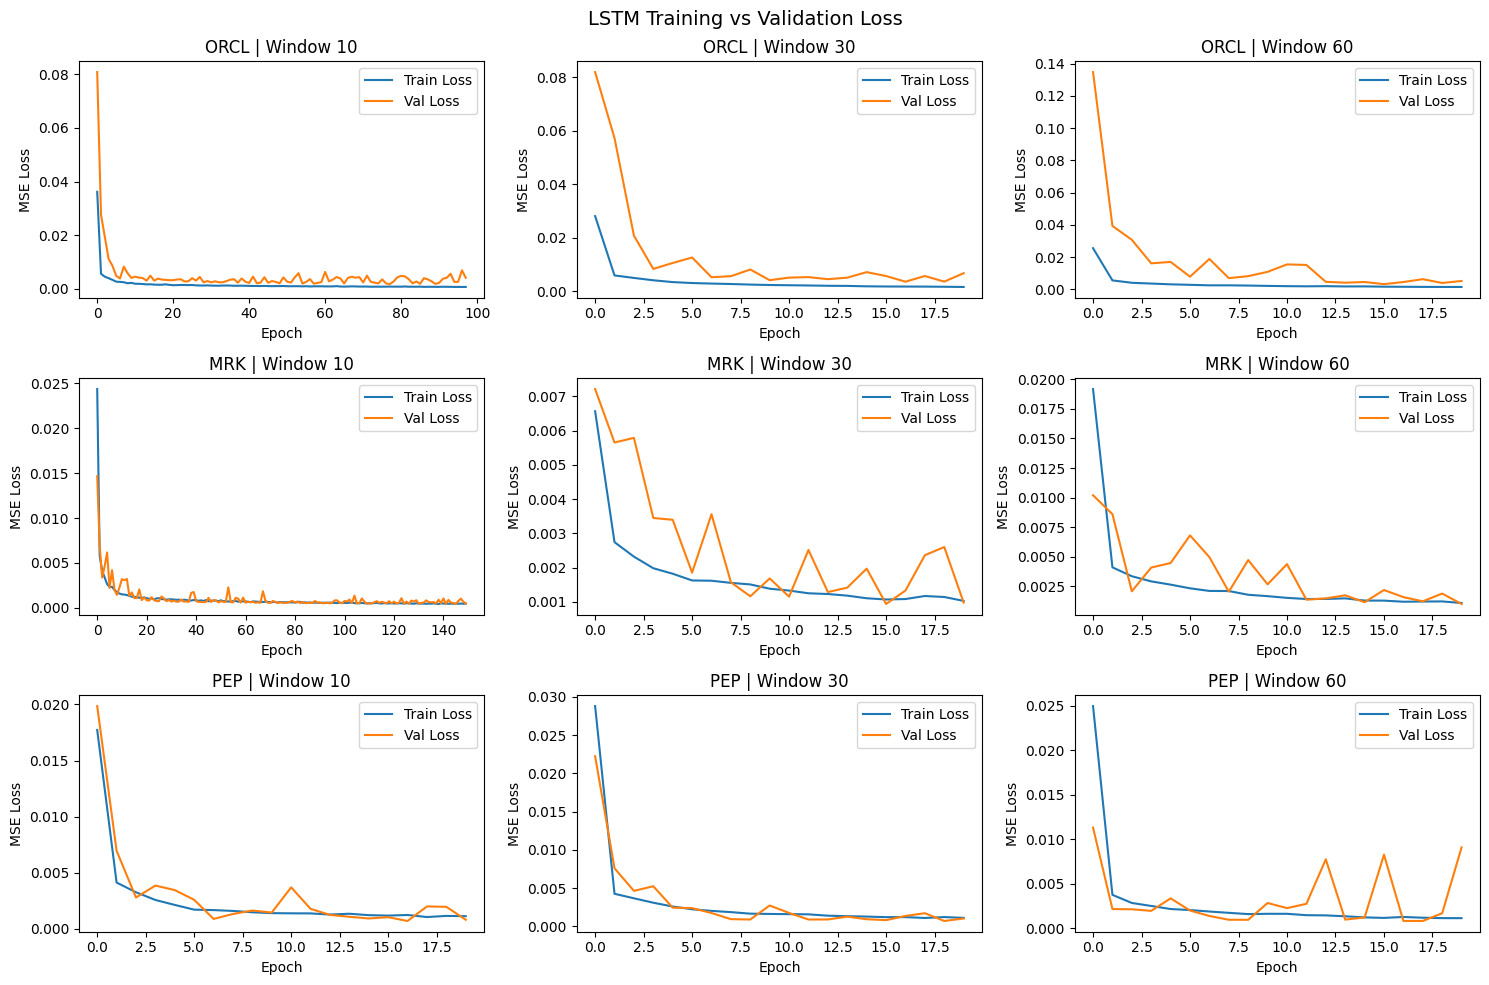

In [50]:
# plot what's happening so we can better tune
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 3, figsize=(15, 10))
fig.suptitle("LSTM Training vs Validation Loss", fontsize=14)

for i, stock in enumerate(target_stocks):
    for j, window in enumerate(lookback_windows):
        ax = axes[i][j]
        history = lstm_results[stock][window]["history"]
        
        ax.plot(history.history["loss"], label="Train Loss")
        ax.plot(history.history["val_loss"], label="Val Loss")
        ax.set_title(f"{stock} | Window {window}")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("MSE Loss")
        ax.legend()

plt.tight_layout()
plt.show()

Honestly - based on the graphs, I'm not sure if continued tuning will give us any returns.
It appears the more information that the models get, the less precise they are, which is why we look good on 10 day windows vs 30 or 60.

In [51]:
# Evaluate LSTM results
for stock in target_stocks:
    for window in lookback_windows:
        y_true = lstm_results[stock][window]["y_true"]
        y_pred = lstm_results[stock][window]["y_pred"]
        result = evaluate_model(y_true, y_pred, stock, "LSTM", window)
        results.append(result)

ORCL - LSTM - Window 10 - MAE: 0.0624, RMSE: 0.0918, MAPE: 2.26%
ORCL - LSTM - Window 30 - MAE: 1.1820, RMSE: 1.3879, MAPE: 40.79%
ORCL - LSTM - Window 60 - MAE: 1.2969, RMSE: 1.4603, MAPE: 44.89%
MRK - LSTM - Window 10 - MAE: 0.0285, RMSE: 0.0355, MAPE: 1.76%
MRK - LSTM - Window 30 - MAE: 0.1577, RMSE: 0.1685, MAPE: 9.70%
MRK - LSTM - Window 60 - MAE: 0.3038, RMSE: 0.3211, MAPE: 18.45%
PEP - LSTM - Window 10 - MAE: 0.2730, RMSE: 0.2764, MAPE: 18.73%
PEP - LSTM - Window 30 - MAE: 0.2772, RMSE: 0.2808, MAPE: 18.99%
PEP - LSTM - Window 60 - MAE: 0.2113, RMSE: 0.2166, MAPE: 14.47%


I am not fully understanding why my scaled values are exceeding 1.0. Generally, when you train using scaled data, the value and test ranges are generally between 0-1.
Edit: The Scaler was fit on training data between 2010-2020. Oracle price from the test split (2022-2024) is significantly higher.

$31 - 2010

$36 - 2015

$48 - 2020

$112 - 2023

$137 - 2024


In [53]:
# Diagnostic — Inverse transform and recheck
stock = "ORCL"
window = 30

y_true_scaled = lstm_results[stock][window]["y_true"]
y_pred_scaled = lstm_results[stock][window]["y_pred"]

# Scaler expects shape (n, n_features) — pad with zeros for other features
def inverse_transform_target(scaler, values):
    dummy = np.zeros((len(values), 4))
    dummy[:, 0] = values
    return scaler.inverse_transform(dummy)[:, 0]

y_true_real = inverse_transform_target(scalers[stock], y_true_scaled)
y_pred_real = inverse_transform_target(scalers[stock], y_pred_scaled)

print("y_true real sample:", y_true_real[:5])
print("y_pred real sample:", y_pred_real[:5])
print("y_true real range:", y_true_real.min(), "→", y_true_real.max())
print("y_pred real range:", y_pred_real.min(), "→", y_pred_real.max())

y_true real sample: [73.01434326 73.95828247 74.67840576 73.6079483  73.62741852]
y_pred real sample: [61.40324965 61.78212375 62.15869159 62.49342354 62.83452241]
y_true real range: 73.01434326171875 → 192.42999267578128
y_pred real range: 61.403249645806 → 76.49630363098436


# Updating the Evaluation function with Inverse Transform and then reruning all the evaluations.
Hopefully this shows us actuall training improvements outside of the first 10 days.

In [54]:
# Updated Evaluation Function with Inverse Transform
def inverse_transform_target(scaler, values):
    dummy = np.zeros((len(values), 4))
    dummy[:, 0] = values
    return scaler.inverse_transform(dummy)[:, 0]

def evaluate_model(y_true, y_pred, stock, model_name, window):
    # Inverse transform to real dollar values
    y_true_real = inverse_transform_target(scalers[stock], y_true)
    y_pred_real = inverse_transform_target(scalers[stock], y_pred)
    
    mae  = mean_absolute_error(y_true_real, y_pred_real)
    rmse = np.sqrt(mean_squared_error(y_true_real, y_pred_real))
    mape = np.mean(np.abs((y_true_real - y_pred_real) / y_true_real)) * 100

    print(f"{stock} - {model_name} - Window {window} - "
          f"MAE: ${mae:.2f} | RMSE: ${rmse:.2f} | MAPE: {mape:.2f}%")

    return {"stock": stock, "model": model_name, "window": window,
            "MAE": mae, "RMSE": rmse, "MAPE": mape}

In [55]:
# Rerun all evaluation with corrected scaling
results = []

# Naive Baseline
for stock in target_stocks:
    for window in lookback_windows:
        y_true = nb_results[stock][window]["y_true"]
        y_pred = nb_results[stock][window]["y_pred"]
        result = evaluate_model(y_true, y_pred, stock, "Naive Baseline", window)
        results.append(result)

# Linear Regression
for stock in target_stocks:
    for window in lookback_windows:
        y_true = lr_results[stock][window]["y_true"]
        y_pred = lr_results[stock][window]["y_pred"]
        result = evaluate_model(y_true, y_pred, stock, "Linear Regression", window)
        results.append(result)

# LSTM
for stock in target_stocks:
    for window in lookback_windows:
        y_true = lstm_results[stock][window]["y_true"]
        y_pred = lstm_results[stock][window]["y_pred"]
        result = evaluate_model(y_true, y_pred, stock, "LSTM", window)
        results.append(result)

ORCL - Naive Baseline - Window 10 - MAE: $1.49 | RMSE: $2.41 | MAPE: 1.27%
ORCL - Naive Baseline - Window 30 - MAE: $1.50 | RMSE: $2.44 | MAPE: 1.25%
ORCL - Naive Baseline - Window 60 - MAE: $1.53 | RMSE: $2.49 | MAPE: 1.25%
MRK - Naive Baseline - Window 10 - MAE: $0.98 | RMSE: $1.39 | MAPE: 0.91%
MRK - Naive Baseline - Window 30 - MAE: $0.98 | RMSE: $1.40 | MAPE: 0.90%
MRK - Naive Baseline - Window 60 - MAE: $0.98 | RMSE: $1.40 | MAPE: 0.89%
PEP - Naive Baseline - Window 10 - MAE: $1.25 | RMSE: $1.69 | MAPE: 0.75%
PEP - Naive Baseline - Window 30 - MAE: $1.22 | RMSE: $1.64 | MAPE: 0.73%
PEP - Naive Baseline - Window 60 - MAE: $1.21 | RMSE: $1.64 | MAPE: 0.73%
ORCL - Linear Regression - Window 10 - MAE: $1.55 | RMSE: $2.50 | MAPE: 1.32%
ORCL - Linear Regression - Window 30 - MAE: $1.59 | RMSE: $2.55 | MAPE: 1.32%
ORCL - Linear Regression - Window 60 - MAE: $1.72 | RMSE: $2.69 | MAPE: 1.40%
MRK - Linear Regression - Window 10 - MAE: $1.05 | RMSE: $1.45 | MAPE: 0.97%
MRK - Linear Regress

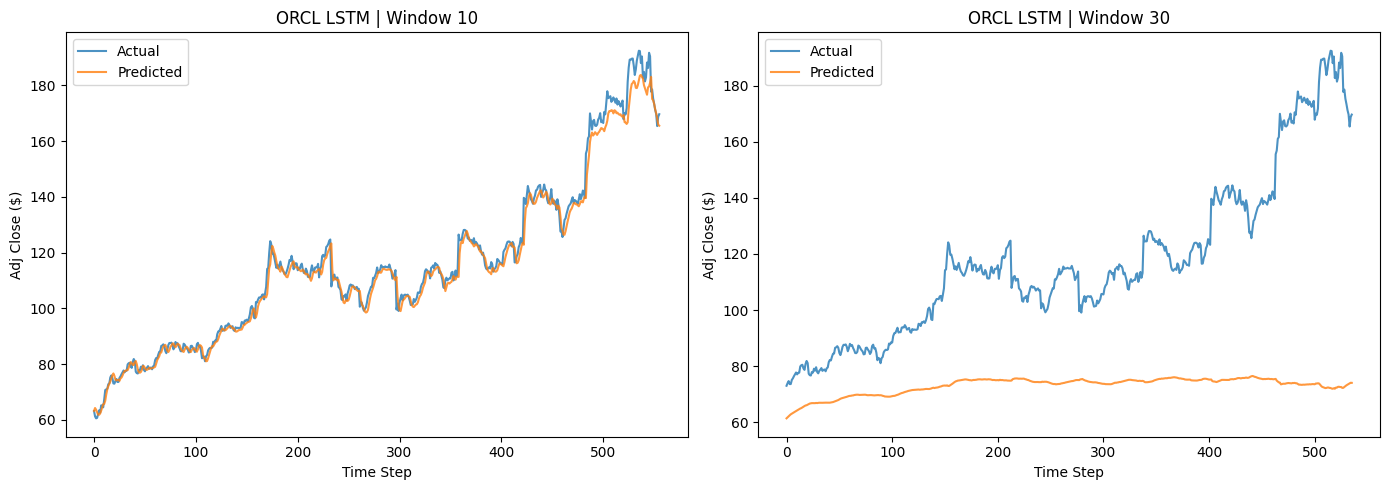

In [56]:
# Diagnostic — Plot ORCL Window 10 vs Window 30 predictions
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, window in enumerate([10, 30]):
    y_true = lstm_results["ORCL"][window]["y_true"]
    y_pred = lstm_results["ORCL"][window]["y_pred"]
    
    y_true_real = inverse_transform_target(scalers["ORCL"], y_true)
    y_pred_real = inverse_transform_target(scalers["ORCL"], y_pred)
    
    ax = axes[idx]
    ax.plot(y_true_real, label="Actual", alpha=0.8)
    ax.plot(y_pred_real, label="Predicted", alpha=0.8)
    ax.set_title(f"ORCL LSTM | Window {window}")
    ax.set_xlabel("Time Step")
    ax.set_ylabel("Adj Close ($)")
    ax.legend()

plt.tight_layout()
plt.show()

Updated version of  LSTM model. After consulting with claude ai, I discovered a couple additional 

In [91]:
# Retrain window 30 and 60 only
import tensorflow as tf
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
tf.keras.backend.clear_session()

EPOCHS = 200
# updating batch size back up to 16 to see if that helps without adding too much noise.
BATCH_SIZE = 16

early_stop = EarlyStopping(
    monitor="val_loss",
    # updating patience to 50 to give the model more time to improve given the smaller learning rate and batch size.
    patience=50,
    restore_best_weights=True
)
# 4-22-26 Updating model to get rid of user warning message.
def build_lstm_model(window, n_features):
    tf.random.set_seed(42)
    model = Sequential()
    model.add(Input(shape=(window, n_features)))
    model.add(LSTM(32, kernel_initializer='glorot_uniform',  # took the value down to 32 units from 64 to try and train better.
                   recurrent_initializer='orthogonal')) # Heavy emphasis from Claude.ai and chatGPT to use orthogonal. Supposed to give a better starting point for the weights.
    model.add(Dropout(0.2))
    model.add(Dense(1))
    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=0.0001,
            clipnorm=1.0  # New addition of clipnorm to prevent exploding gradients and help with convergence given the smaller dataset and learning rate.
        ),
        loss='mse'
    )
    return model

for stock in target_stocks:
    for window in [30, 60]:
        print(f"Retraining {stock} | Window {window}...")

        X_train = sequence_data[stock][window]["X_train"]
        y_train = sequence_data[stock][window]["y_train"]
        X_val   = sequence_data[stock][window]["X_val"]
        y_val   = sequence_data[stock][window]["y_val"]
        X_test  = sequence_data[stock][window]["X_test"]
        y_test  = sequence_data[stock][window]["y_test"]

        model = build_lstm_model(window, n_features)

        history = model.fit(
            X_train, y_train,
            validation_data=(X_val, y_val),
            epochs=EPOCHS,
            batch_size=BATCH_SIZE,
            callbacks=[early_stop],
            verbose=0
        )

        y_pred = model.predict(X_test, verbose=0).flatten()

        lstm_results[stock][window] = {
            "y_true": y_test,
            "y_pred": y_pred,
            "model": model,
            "history": history
        }

        epochs_run = len(history.history["loss"])
        print(f"  Done — {epochs_run} epochs | Final val_loss: {history.history['val_loss'][-1]:.6f}")

Retraining ORCL | Window 30...
  Done — 97 epochs | Final val_loss: 0.008913
Retraining ORCL | Window 60...
  Done — 150 epochs | Final val_loss: 0.005110
Retraining MRK | Window 30...
  Done — 200 epochs | Final val_loss: 0.000859
Retraining MRK | Window 60...
  Done — 50 epochs | Final val_loss: 0.001314
Retraining PEP | Window 30...
  Done — 50 epochs | Final val_loss: 0.001016
Retraining PEP | Window 60...
  Done — 50 epochs | Final val_loss: 0.002889


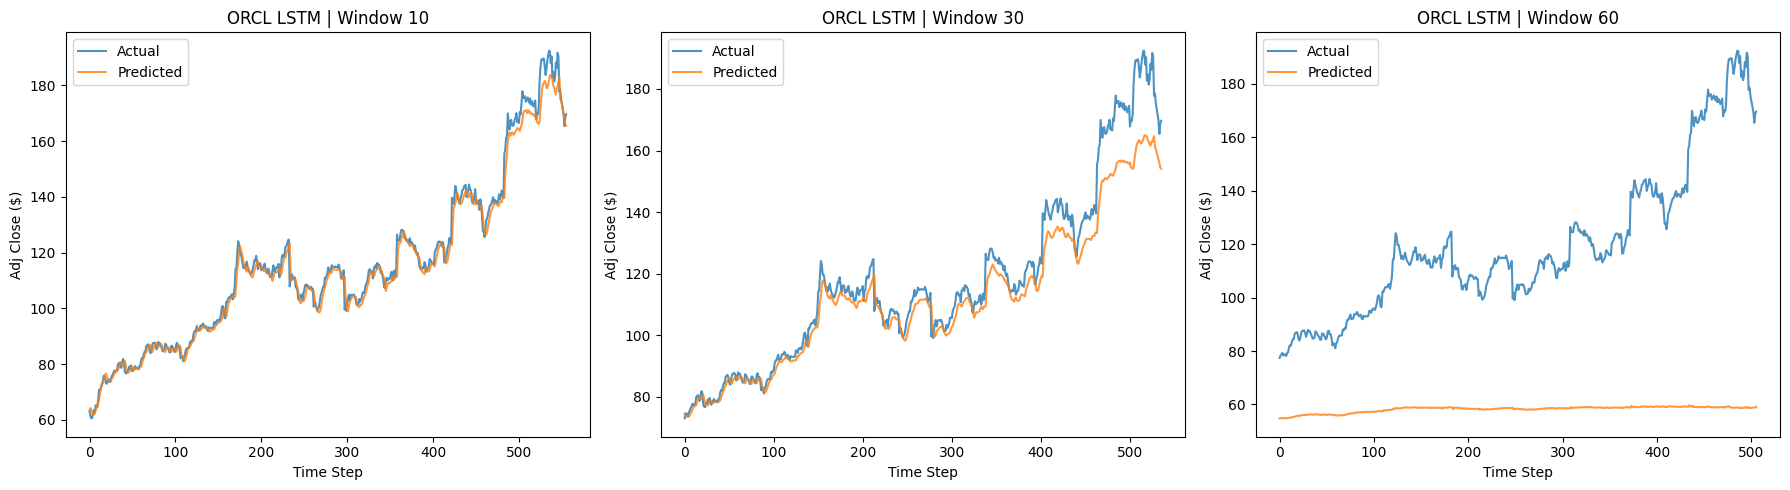

In [59]:
# Diagnostic — Plot all 3 windows for ORCL
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, window in enumerate(lookback_windows):
    y_true = lstm_results["ORCL"][window]["y_true"]
    y_pred = lstm_results["ORCL"][window]["y_pred"]
    
    y_true_real = inverse_transform_target(scalers["ORCL"], y_true)
    y_pred_real = inverse_transform_target(scalers["ORCL"], y_pred)
    
    ax = axes[idx]
    ax.plot(y_true_real, label="Actual", alpha=0.8)
    ax.plot(y_pred_real, label="Predicted", alpha=0.8)
    ax.set_title(f"ORCL LSTM | Window {window}")
    ax.set_xlabel("Time Step")
    ax.set_ylabel("Adj Close ($)")
    ax.legend()

plt.tight_layout()
plt.show()

At this point, I've tried multiple different pathways for trying to help the model learn for 60 days. We were able to get it the 30 day window to learn, however, the more I play with the amount of epochs and patience, the more of a tradeoff I'm taking in time to run the report.

I honestly think this is the true result for this type of test, which is why a lot of consumers aren't makign a model that understands this information to make money in the stock market.

In [60]:
# Rerun LSTM evaluation with retrained models
results = [r for r in results if r["model"] != "LSTM"]

for stock in target_stocks:
    for window in lookback_windows:
        y_true = lstm_results[stock][window]["y_true"]
        y_pred = lstm_results[stock][window]["y_pred"]
        result = evaluate_model(y_true, y_pred, stock, "LSTM", window)
        results.append(result)

ORCL - LSTM - Window 10 - MAE: $2.35 | RMSE: $3.46 | MAPE: 1.91%
ORCL - LSTM - Window 30 - MAE: $5.65 | RMSE: $8.50 | MAPE: 4.08%
ORCL - LSTM - Window 60 - MAE: $61.65 | RMSE: $67.35 | MAPE: 49.19%
MRK - LSTM - Window 10 - MAE: $1.62 | RMSE: $2.02 | MAPE: 1.46%
MRK - LSTM - Window 30 - MAE: $3.20 | RMSE: $3.71 | MAPE: 2.85%
MRK - LSTM - Window 60 - MAE: $43.62 | RMSE: $44.48 | MAPE: 39.24%
PEP - LSTM - Window 10 - MAE: $24.38 | RMSE: $24.68 | MAPE: 14.49%
PEP - LSTM - Window 30 - MAE: $52.53 | RMSE: $52.79 | MAPE: 31.20%
PEP - LSTM - Window 60 - MAE: $72.90 | RMSE: $73.16 | MAPE: 43.36%


Was nearly inclined to move on to the next steps, however, Pepsi does not seem like it's learning at all in any of the windows.
It has a 14% Mean absolutel Percentage error, I'd overlook it if it was within 3%, but 14% is the lowest in window 10, and the percentage nearly doubles in window 30 and higher in Window 60.

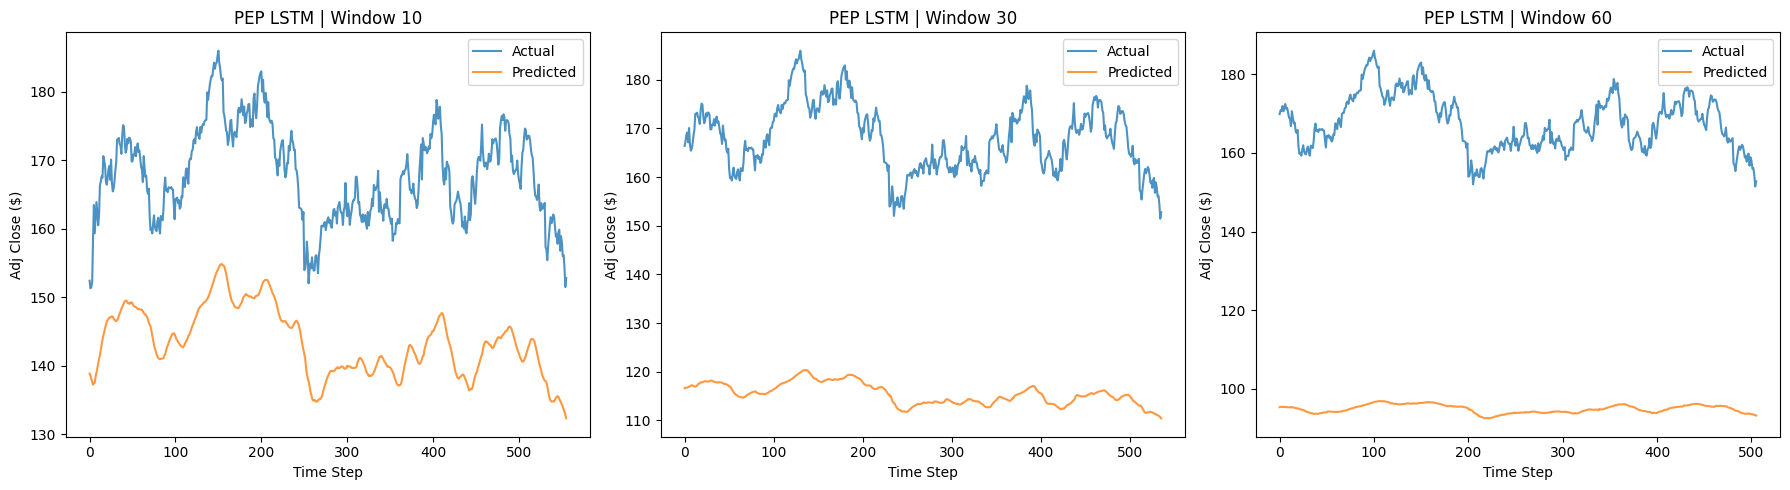

In [61]:
# Plot the windows for Pepsi
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, window in enumerate(lookback_windows):
    y_true = lstm_results["PEP"][window]["y_true"]
    y_pred = lstm_results["PEP"][window]["y_pred"]
    
    y_true_real = inverse_transform_target(scalers["PEP"], y_true)
    y_pred_real = inverse_transform_target(scalers["PEP"], y_pred)
    
    ax = axes[idx]
    ax.plot(y_true_real, label="Actual", alpha=0.8)
    ax.plot(y_pred_real, label="Predicted", alpha=0.8)
    ax.set_title(f"PEP LSTM | Window {window}")
    ax.set_xlabel("Time Step")
    ax.set_ylabel("Adj Close ($)")
    ax.legend()

plt.tight_layout()
plt.show()

At least Window 10 tried. Window 30 and 60 did not perform at all.
Let's try to build a stronger LSTM model for PEPSI only.
We're going to try to adjust the dropout rate from 0.2 to 0.1 with the hope that the model is able to fit stronger to the training pattern's behavior.
I'm going to significantly drop the learning rate to 0.00005 to try and let it find a better minimum.
Because it's only one stock, I'm going to adjust the epochs to 300, and change the patience to 125. Possibly waiting too long, but I'm not sure what will happen. My thought is that with it only being one stock, I can sacrifice the amount of time it should run as a tradeoff.

AI suggests adjusting the LSTM units, however, I'm going to leave that at 64. I don't think it makes that big of a difference at the moment.

In [63]:
# Retrain PEP only with adjusted hyperparameters
tf.keras.backend.clear_session()

PEP_EPOCHS = 300
PEP_BATCH_SIZE = 8

pep_early_stop = EarlyStopping(
    monitor="val_loss",
    patience=125,
    restore_best_weights=True
)

def build_pep_lstm(window, n_features):
    tf.random.set_seed(42)
    model = Sequential()
    model.add(LSTM(64, input_shape=(window, n_features),
                   kernel_initializer='glorot_uniform',
                   recurrent_initializer='orthogonal'))
    model.add(Dropout(0.1))
    model.add(Dense(1))
    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=0.00005,
            clipnorm=1.0
        ),
        loss='mse'
    )
    return model

for window in lookback_windows:
    print(f"Retraining PEP | Window {window}...")

    X_train = sequence_data["PEP"][window]["X_train"]
    y_train = sequence_data["PEP"][window]["y_train"]
    X_val   = sequence_data["PEP"][window]["X_val"]
    y_val   = sequence_data["PEP"][window]["y_val"]
    X_test  = sequence_data["PEP"][window]["X_test"]
    y_test  = sequence_data["PEP"][window]["y_test"]

    model = build_pep_lstm(window, n_features)

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=PEP_EPOCHS,
        batch_size=PEP_BATCH_SIZE,
        callbacks=[pep_early_stop],
        verbose=0
    )

    y_pred = model.predict(X_test, verbose=0).flatten()

    lstm_results["PEP"][window] = {
        "y_true": y_test,
        "y_pred": y_pred,
        "model": model,
        "history": history
    }

    epochs_run = len(history.history["loss"])
    print(f"  Done — {epochs_run} epochs | Final val_loss: {history.history['val_loss'][-1]:.6f}")

Retraining PEP | Window 10...


C:\Users\Kasual1\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  Done — 300 epochs | Final val_loss: 0.000651
Retraining PEP | Window 30...
  Done — 125 epochs | Final val_loss: 0.000782
Retraining PEP | Window 60...
  Done — 125 epochs | Final val_loss: 0.003965


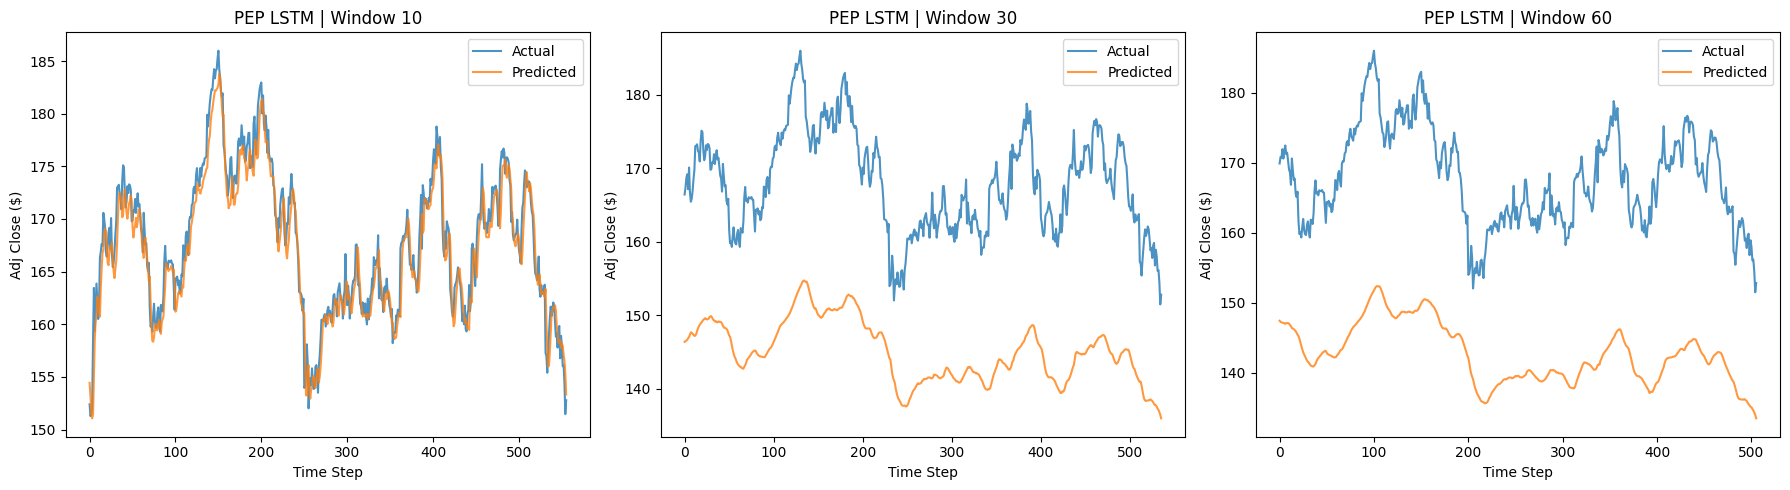

In [64]:
# Diagnostic — Plot all 3 windows for PEP retrain
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, window in enumerate(lookback_windows):
    y_true = lstm_results["PEP"][window]["y_true"]
    y_pred = lstm_results["PEP"][window]["y_pred"]
    
    y_true_real = inverse_transform_target(scalers["PEP"], y_true)
    y_pred_real = inverse_transform_target(scalers["PEP"], y_pred)
    
    ax = axes[idx]
    ax.plot(y_true_real, label="Actual", alpha=0.8)
    ax.plot(y_pred_real, label="Predicted", alpha=0.8)
    ax.set_title(f"PEP LSTM | Window {window}")
    ax.set_xlabel("Time Step")
    ax.set_ylabel("Adj Close ($)")
    ax.legend()

plt.tight_layout()
plt.show()

I lost 15 minutes to this, and while it performed better at window 10, I'm still curious if I can get better performance on window 30 and 60 by extending the patience. 

In [65]:
# Retrain PEP only with adjusted hyperparameters
tf.keras.backend.clear_session()

PEP_EPOCHS = 300
PEP_BATCH_SIZE = 8

pep_early_stop = EarlyStopping(
    monitor="val_loss",
    patience=200,
    restore_best_weights=True
)

def build_pep_lstm(window, n_features):
    tf.random.set_seed(42)
    model = Sequential()
    model.add(LSTM(64, input_shape=(window, n_features),
                   kernel_initializer='glorot_uniform',
                   recurrent_initializer='orthogonal'))
    model.add(Dropout(0.1))
    model.add(Dense(1))
    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=0.00005,
            clipnorm=1.0
        ),
        loss='mse'
    )
    return model

for window in lookback_windows:
    print(f"Retraining PEP | Window {window}...")

    X_train = sequence_data["PEP"][window]["X_train"]
    y_train = sequence_data["PEP"][window]["y_train"]
    X_val   = sequence_data["PEP"][window]["X_val"]
    y_val   = sequence_data["PEP"][window]["y_val"]
    X_test  = sequence_data["PEP"][window]["X_test"]
    y_test  = sequence_data["PEP"][window]["y_test"]

    model = build_pep_lstm(window, n_features)

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=PEP_EPOCHS,
        batch_size=PEP_BATCH_SIZE,
        callbacks=[pep_early_stop],
        verbose=0
    )

    y_pred = model.predict(X_test, verbose=0).flatten()

    lstm_results["PEP"][window] = {
        "y_true": y_test,
        "y_pred": y_pred,
        "model": model,
        "history": history
    }

    epochs_run = len(history.history["loss"])
    print(f"  Done — {epochs_run} epochs | Final val_loss: {history.history['val_loss'][-1]:.6f}")

Retraining PEP | Window 10...


C:\Users\Kasual1\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  Done — 300 epochs | Final val_loss: 0.000534
Retraining PEP | Window 30...
  Done — 200 epochs | Final val_loss: 0.000699
Retraining PEP | Window 60...
  Done — 200 epochs | Final val_loss: 0.000516


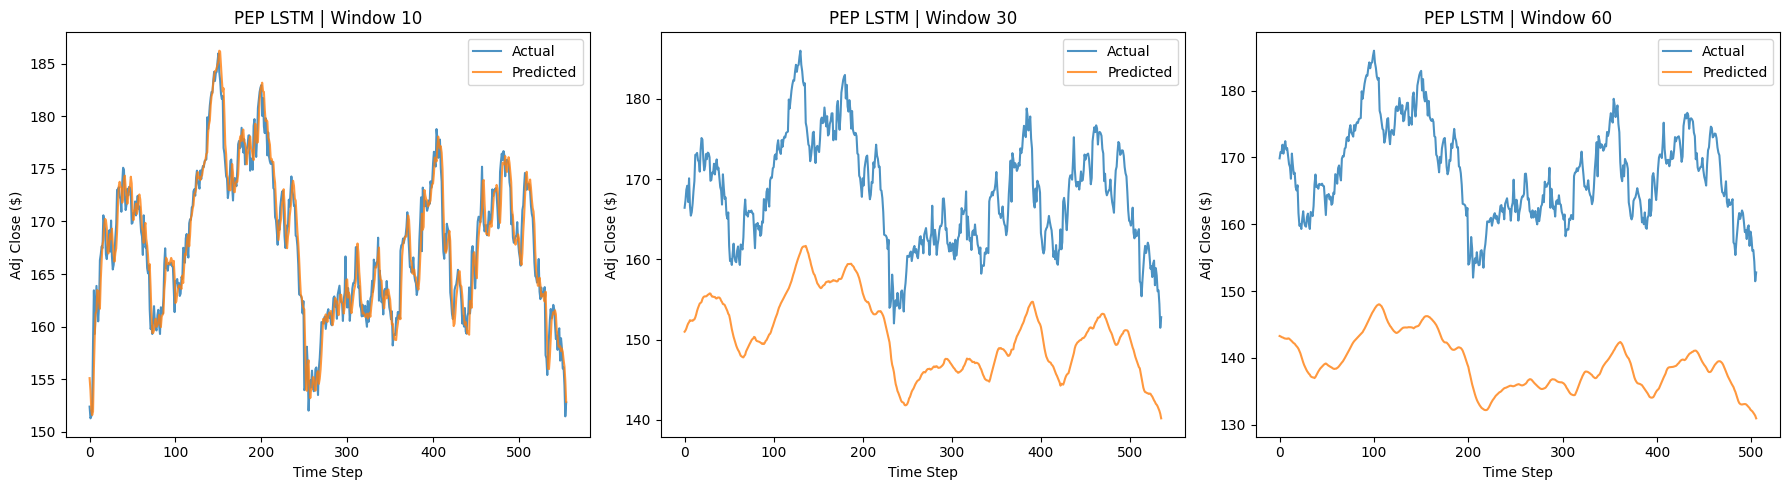

In [66]:
# Diagnostic — Plot all 3 windows for PEP retrain
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, window in enumerate(lookback_windows):
    y_true = lstm_results["PEP"][window]["y_true"]
    y_pred = lstm_results["PEP"][window]["y_pred"]
    
    y_true_real = inverse_transform_target(scalers["PEP"], y_true)
    y_pred_real = inverse_transform_target(scalers["PEP"], y_pred)
    
    ax = axes[idx]
    ax.plot(y_true_real, label="Actual", alpha=0.8)
    ax.plot(y_pred_real, label="Predicted", alpha=0.8)
    ax.set_title(f"PEP LSTM | Window {window}")
    ax.set_xlabel("Time Step")
    ax.set_ylabel("Adj Close ($)")
    ax.legend()

plt.tight_layout()
plt.show()

Window 30 and Window 60 still aren't learning as well.
I think based on the criteria, it's failing due to the specific parameters I've set.
I think if I adding an addition 200 epoch and increased patience more, that would help the 30 window for pepsi continue to grow, however, I'm still uncertain about it performing well for window 60.
Honestly, given how well this is performing for window 10 across the board, I'd question how much better a candlestick pattern analysis would learn instead of using pricing history.



In [67]:
# Overall evaluations with all of the retrained models.
results = []

# Naive Baseline
for stock in target_stocks:
    for window in lookback_windows:
        y_true = nb_results[stock][window]["y_true"]
        y_pred = nb_results[stock][window]["y_pred"]
        result = evaluate_model(y_true, y_pred, stock, "Naive Baseline", window)
        results.append(result)

# Linear Regression
for stock in target_stocks:
    for window in lookback_windows:
        y_true = lr_results[stock][window]["y_true"]
        y_pred = lr_results[stock][window]["y_pred"]
        result = evaluate_model(y_true, y_pred, stock, "Linear Regression", window)
        results.append(result)

# LSTM
for stock in target_stocks:
    for window in lookback_windows:
        y_true = lstm_results[stock][window]["y_true"]
        y_pred = lstm_results[stock][window]["y_pred"]
        result = evaluate_model(y_true, y_pred, stock, "LSTM", window)
        results.append(result)

ORCL - Naive Baseline - Window 10 - MAE: $1.49 | RMSE: $2.41 | MAPE: 1.27%
ORCL - Naive Baseline - Window 30 - MAE: $1.50 | RMSE: $2.44 | MAPE: 1.25%
ORCL - Naive Baseline - Window 60 - MAE: $1.53 | RMSE: $2.49 | MAPE: 1.25%
MRK - Naive Baseline - Window 10 - MAE: $0.98 | RMSE: $1.39 | MAPE: 0.91%
MRK - Naive Baseline - Window 30 - MAE: $0.98 | RMSE: $1.40 | MAPE: 0.90%
MRK - Naive Baseline - Window 60 - MAE: $0.98 | RMSE: $1.40 | MAPE: 0.89%
PEP - Naive Baseline - Window 10 - MAE: $1.25 | RMSE: $1.69 | MAPE: 0.75%
PEP - Naive Baseline - Window 30 - MAE: $1.22 | RMSE: $1.64 | MAPE: 0.73%
PEP - Naive Baseline - Window 60 - MAE: $1.21 | RMSE: $1.64 | MAPE: 0.73%
ORCL - Linear Regression - Window 10 - MAE: $1.55 | RMSE: $2.50 | MAPE: 1.32%
ORCL - Linear Regression - Window 30 - MAE: $1.59 | RMSE: $2.55 | MAPE: 1.32%
ORCL - Linear Regression - Window 60 - MAE: $1.72 | RMSE: $2.69 | MAPE: 1.40%
MRK - Linear Regression - Window 10 - MAE: $1.05 | RMSE: $1.45 | MAPE: 0.97%
MRK - Linear Regress

In [68]:
# Summarize results in a DataFrame
import pandas as pd
results_df = pd.DataFrame(results)

print("\nFinal Evaluation Results:")
# pivot table for clean comparison
summary = results_df.pivot_table(
    index=["stock", "window"],
    columns="model",
    values=["MAE", "RMSE", "MAPE"])
print(summary)


Final Evaluation Results:
                    MAE                                        MAPE  \
model              LSTM Linear Regression Naive Baseline       LSTM   
stock window                                                          
MRK   10       1.622087          1.050473       0.979474   1.464558   
      30       3.197398          1.059513       0.977885   2.853576   
      60      43.616344          1.110949       0.975178  39.236761   
ORCL  10       2.349239          1.550261       1.488165   1.906774   
      30       5.646955          1.592148       1.496382   4.078447   
      60      61.645962          1.721718       1.530347  49.188541   
PEP   10       1.474551          1.382193       1.248250   0.881670   
      30      17.341964          1.447173       1.215504  10.272978   
      60      28.792913          1.506372       1.212196  17.092515   

                                                    RMSE                    \
model        Linear Regression Naive Basel

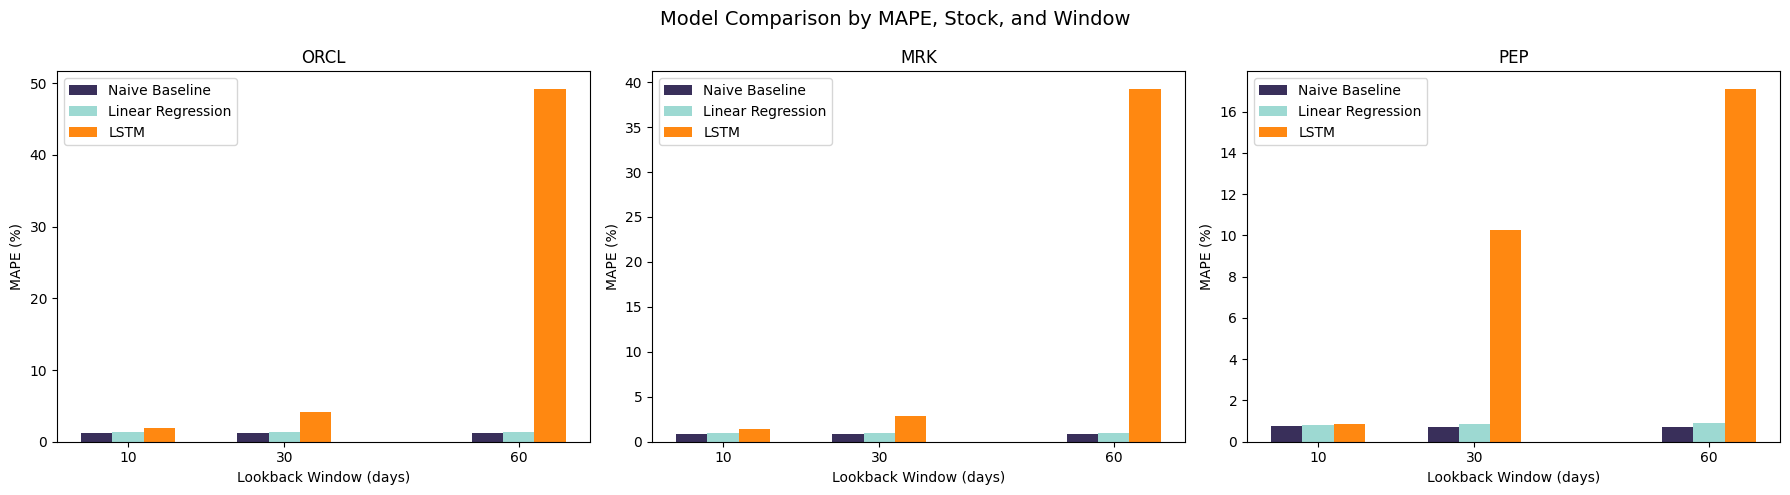

In [72]:
# Bar chart comparison of MAPE by model across stocks and windows
import matplotlib.pyplot as plt
import numpy as np

# adjusting width to be wider to improve readability given we have 3 models and 3 windows.
width = 4
models = ["Naive Baseline", "Linear Regression", "LSTM"]
colors = ["#392F5A", "#9DD9D2", "#FF8811"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Model Comparison by MAPE, Stock, and Window", fontsize=14)

for idx, stock in enumerate(target_stocks):
    ax = axes[idx]
    stock_data = results_df[results_df["stock"] == stock]
    
    for i, (model, color) in enumerate(zip(models, colors)):
        model_data = stock_data[stock_data["model"] == model]
        offset = (i - 1) * width  # center the bars around the window value
        ax.bar(
            model_data["window"] + offset,
            model_data["MAPE"],
            width,
            label=model,
            color=color
        )
    
    ax.set_title(f"{stock}")
    ax.set_xlabel("Lookback Window (days)")
    ax.set_ylabel("MAPE (%)")
    ax.set_xticks(lookback_windows)
    ax.legend()

plt.tight_layout()
plt.show()

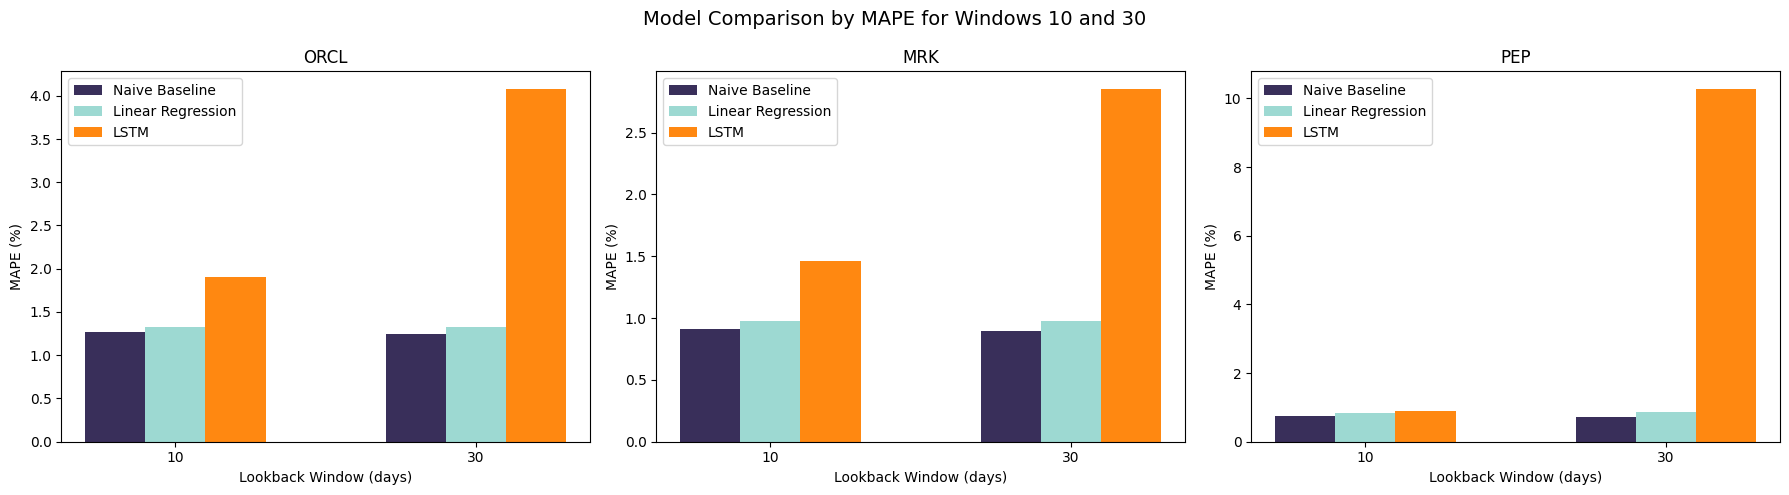

In [74]:
# isolating the charts to window 10 and 30 for better readibility of MAPE Comparison

models = ["Naive Baseline", "Linear Regression", "LSTM"]
colors = ["#392F5A", "#9DD9D2", "#FF8811"]
windows_subset = [10, 30]
width = 4

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Model Comparison by MAPE for Windows 10 and 30", fontsize=14)

for idx, stock in enumerate(target_stocks):
    ax = axes[idx]
    stock_data = results_df[
        (results_df["stock"] == stock) &
        (results_df["window"].isin(windows_subset))
    ]
    
    for i, (model, color) in enumerate(zip(models, colors)):
        model_data = stock_data[stock_data["model"] == model]
        offset = (i - 1) * width  # center the bars around the window value
        ax.bar(
            model_data["window"] + offset,
            model_data["MAPE"],
            width,
            label=model,
            color=color
        )
    
    ax.set_title(f"{stock}")
    ax.set_xlabel("Lookback Window (days)")
    ax.set_ylabel("MAPE (%)")
    ax.set_xticks(windows_subset)
    ax.legend()
plt.tight_layout()
plt.savefig("model_comparison_mape_windows_10_30.png", dpi=300)
plt.show()

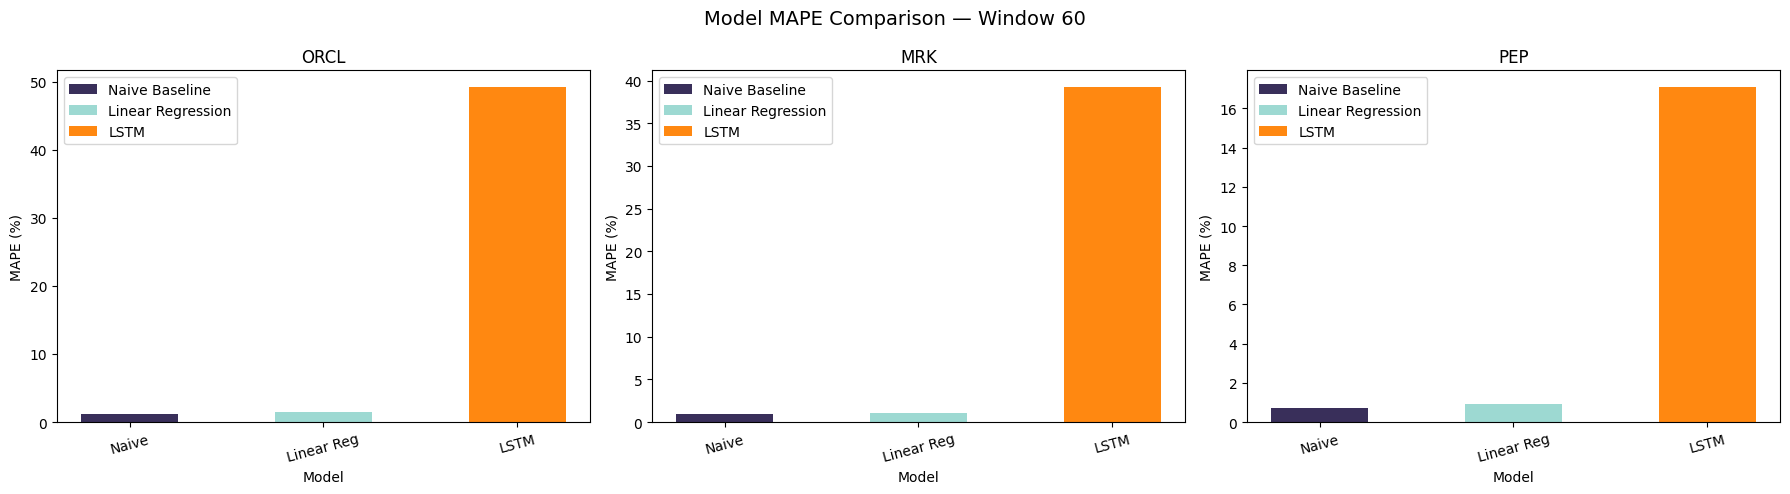

In [76]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Model MAPE Comparison — Window 60", fontsize=14)

for idx, stock in enumerate(target_stocks):
    ax = axes[idx]
    stock_data = results_df[results_df["stock"] == stock]
    stock_data = stock_data[stock_data["window"] == 60]

    for i, (model, color) in enumerate(zip(models, colors)):
        model_data = stock_data[stock_data["model"] == model]
        ax.bar(
            i,
            model_data["MAPE"].values[0],
            width=0.5,
            label=model,
            color=color
        )

    ax.set_title(f"{stock}")
    ax.set_xlabel("Model")
    ax.set_ylabel("MAPE (%)")
    ax.set_xticks([0, 1, 2])
    ax.set_xticklabels(["Naive", "Linear Reg", "LSTM"], rotation=15)
    ax.legend()

plt.tight_layout()
plt.savefig("chart_mape_window_60.png", dpi=300)
plt.show()

# Rebuild Scaler to utilize a K-10 CV Split
Preliminary testing splits give no weight to the 30 or 60 LSTM windows, so I will scale it down to the 10 day window for this purpose of the project.

In [ ]:
# kfold cross validation for time series using expanding window approach
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import tensorflow as tf
import random

n_splits = 10 # number of folds for cross-validation
window = 10 # only testing on 10 day window for this given the performance we saw with the other windows. Would like to see how robust that model is with more data.
n_features = 4
features = ["Adj Close", "Open", "High", "Low"]

tscv = TimeSeriesSplit(n_splits=n_splits)

# need to add a random seed for reproducibility of the LSTM results across folds.
def set_seeds(seed=42):
    np.random.seed(seed)
    random.seed(seed)
    tf.random.set_seed(seed)

SEED = 42
set_seeds(seed)

# storing kfold scores
kfold_results = {
    stock: {
        "Naive Baseline": [],
        "Linear Regression": [],
        "LSTM": []
    } for stock in target_stocks
}

for stock in target_stocks:
    print(f"\nStarting Time Series Cross-Validation for {stock}...")
    data = feature_data[stock][["Date"] + features].copy()
    data = data.reset_index(drop=True)
    
    X_raw = data[features].values


    for fold, (train_idx, test_idx) in enumerate(tscv.split(X_raw)):
        print(f"  Fold {fold + 1}/{n_splits} — Train: {len(train_idx)} samples | Test: {len(test_idx)} samples")
        
        train_raw = X_raw[train_idx]  # adjust for window
        test_raw = X_raw[test_idx]    # adjust for window  
        # Fresh Scaler per fold - fit on train only
        fold_scaler = MinMaxScaler()
               
        X_train_scaled = fold_scaler.fit_transform(train_raw)
        X_test_scaled = fold_scaler.transform(test_raw)

        # Recreate sequences with the fold-specific scaled data
        X_train, y_train = create_sequences(X_train_scaled, window)
        X_test, y_test = create_sequences(X_test_scaled, window)


        # inverse transform function for evaluation later
        def inverse_transform_target(scaler, values):
            dummy = np.zeros((len(values), n_features))
            dummy[:, 0] = values
            return scaler.inverse_transform(dummy)[:, 0]
        
        y_test_real = inverse_transform_target(fold_scaler, y_test)

        # Naive Baseline
        y_pred_nb = X_test[:, -1, 0]  # last day in sequence, Adj Close column
        y_pred_nb_real = inverse_transform_target(fold_scaler, y_pred_nb)
        nb_mae = mean_absolute_error(y_test_real, y_pred_nb_real)
        mape_nb = np.mean(np.abs((y_test_real - y_pred_nb_real) / y_test_real)) * 100
        
        kfold_results[stock]["Naive Baseline"].append((nb_mae, mape_nb))

        # Linear Regression
        X_train_lr = X_train.reshape(len(X_train), -1)
        X_test_lr = X_test.reshape(len(X_test), -1)
        lr_model = LinearRegression()
        lr_model.fit(X_train_lr, y_train)
        y_pred_lr = lr_model.predict(X_test_lr)
        y_pred_lr_real = inverse_transform_target(fold_scaler, y_pred_lr)
        lr_mae = mean_absolute_error(y_test_real, y_pred_lr_real)
        mape_lr = np.mean(np.abs((y_test_real - y_pred_lr_real) / y_test_real)) * 100
        kfold_results[stock]["Linear Regression"].append((lr_mae, mape_lr))

        # LSTM
        val_split = int(len(X_train) * 0.8)
        x_tr, y_tr = X_train[:val_split], y_train[:val_split]
        x_val, y_val = X_train[val_split:], y_train[val_split:]
        
        
        # Add Seed logic
        set_seeds(seed)
        tf.keras.backend.clear_session()
        lstm_model = build_lstm_model(window, n_features)
        lstm_model.fit(
            x_tr, y_tr,
            validation_data=(x_val, y_val),
            epochs=100,
            batch_size=8,
            callbacks=[EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)],
            verbose=0
        )
        
        y_pred_lstm = lstm_model.predict(X_test).flatten()
        y_pred_lstm_real = inverse_transform_target(fold_scaler, y_pred_lstm)
        lstm_mae = mean_absolute_error(y_test_real, y_pred_lstm_real)
        mape_lstm = np.mean(np.abs((y_test_real - y_pred_lstm_real) / y_test_real)) * 100
        kfold_results[stock]["LSTM"].append((lstm_mae, mape_lstm))

        print(f"    Naive Baseline — MAE: ${nb_mae:.2f} | MAPE: {mape_nb:.2f}%")
        print(f"    Linear Regression — MAE: ${lr_mae:.2f} | MAPE: {mape_lr:.2f}%")
        print(f"    LSTM — MAE: ${lstm_mae:.2f} | MAPE: {mape_lstm:.2f}%")
# Summarize kfold results
print("\nK-Fold Cross-Validation Results (MAE, MAPE):")
for model_name, scores in kfold_results[stock].items():
    avg_mae = np.mean([s[0] for s in scores])
    avg_mape = np.mean([s[1] for s in scores])
    print(f"{stock} - {model_name} — Avg MAE: ${avg_mae:.2f} | Avg MAPE: {avg_mape:.2f}%")



Starting Time Series Cross-Validation for ORCL...
  Fold 1/10 — Train: 348 samples | Test: 342 samples


C:\Users\Kasual1\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step
    Naive Baseline — MAE: $0.36 | MAPE: 1.49%
    Linear Regression — MAE: $0.38 | MAPE: 1.58%
    LSTM — MAE: $0.75 | MAPE: 3.08%
  Fold 2/10 — Train: 690 samples | Test: 342 samples


C:\Users\Kasual1\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
    Naive Baseline — MAE: $0.27 | MAPE: 0.96%
    Linear Regression — MAE: $0.28 | MAPE: 1.00%
    LSTM — MAE: $0.59 | MAPE: 2.08%
  Fold 3/10 — Train: 1032 samples | Test: 342 samples


...

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
    Naive Baseline — MAE: $0.99 | MAPE: 0.71%
    Linear Regression — MAE: $1.03 | MAPE: 0.75%
    LSTM — MAE: $10.84 | MAPE: 7.65%
  Fold 9/10 — Train: 3084 samples | Test: 342 samples


C:\Users\Kasual1\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
    Naive Baseline — MAE: $1.34 | MAPE: 0.81%
    Linear Regression — MAE: $1.40 | MAPE: 0.85%
    LSTM — MAE: $2.06 | MAPE: 1.25%
  Fold 10/10 — Train: 3426 samples | Test: 342 samples


C:\Users\Kasual1\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
    Naive Baseline — MAE: $1.25 | MAPE: 0.76%
    Linear Regression — MAE: $1.32 | MAPE: 0.80%
    LSTM — MAE: $9.66 | MAPE: 5.82%

K-Fold Cross-Validation Results (MAE, MAPE):
PEP - Naive Baseline — Avg MAE: $0.77 | Avg MAPE: 0.74%
PEP - Linear Regression — Avg MAE: $0.80 | Avg MAPE: 0.77%
PEP - LSTM — Avg MAE: $4.77 | Avg MAPE: 4.43%


In [78]:
# Full k-Fold Summary Table
print("\n" + "="*65)
print("K-FOLD CROSS VALIDATION SUMMARY (Window=10, k=10)")
print("="*65)

for stock in target_stocks:
    print(f"\n{stock}:")
    for model_name, scores in kfold_results[stock].items():
        mapes = [s[1] for s in scores]
        maes  = [s[0] for s in scores]
        print(f"  {model_name}:")
        print(f"    MAE  — Mean: ${np.mean(maes):.2f} | Std: ${np.std(maes):.2f}")
        print(f"    MAPE — Mean: {np.mean(mapes):.2f}% | Std: {np.std(mapes):.2f}%")


K-FOLD CROSS VALIDATION SUMMARY (Window=10, k=10)

ORCL:
  Naive Baseline:
    MAE  — Mean: $0.64 | Std: $0.46
    MAPE — Mean: 1.12% | Std: 0.23%
  Linear Regression:
    MAE  — Mean: $0.66 | Std: $0.48
    MAPE — Mean: 1.16% | Std: 0.24%
  LSTM:
    MAE  — Mean: $1.46 | Std: $1.26
    MAPE — Mean: 2.42% | Std: 0.56%

MRK:
  Naive Baseline:
    MAE  — Mean: $0.54 | Std: $0.27
    MAPE — Mean: 0.92% | Std: 0.13%
  Linear Regression:
    MAE  — Mean: $0.57 | Std: $0.27
    MAPE — Mean: 0.98% | Std: 0.17%
  LSTM:
    MAE  — Mean: $1.43 | Std: $1.35
    MAPE — Mean: 2.21% | Std: 0.94%

PEP:
  Naive Baseline:
    MAE  — Mean: $0.77 | Std: $0.39
    MAPE — Mean: 0.74% | Std: 0.16%
  Linear Regression:
    MAE  — Mean: $0.80 | Std: $0.41
    MAPE — Mean: 0.77% | Std: 0.15%
  LSTM:
    MAE  — Mean: $2.02 | Std: $1.10
    MAPE — Mean: 2.19% | Std: 1.34%


# Run the Paired t-test

In [79]:
# T-test scaffolding from Claude ai
# Paired t-test — LSTM vs Naive Baseline and Linear Regression vs Naive Baseline
from scipy.stats import ttest_rel

print("\n" + "="*65)
print("PAIRED T-TEST RESULTS (alpha = 0.05)")
print("="*65)

comparisons = [
    ("Linear Regression", "Naive Baseline"),
    ("LSTM", "Naive Baseline")
]

for stock in target_stocks:
    print(f"\n{stock}:")
    for model_a, model_b in comparisons:
        scores_a = [s[1] for s in kfold_results[stock][model_a]]
        scores_b = [s[1] for s in kfold_results[stock][model_b]]
        
        t_stat, p_value = ttest_rel(scores_a, scores_b)
        
        significant = "SIGNIFICANT" if p_value < 0.05 else "NOT SIGNIFICANT"
        direction = "worse" if np.mean(scores_a) > np.mean(scores_b) else "better"
        
        print(f"  {model_a} vs {model_b}:")
        print(f"    t-statistic: {t_stat:.4f} | p-value: {p_value:.4f} | {significant}")
        print(f"    {model_a} performs {direction} than {model_b}")


PAIRED T-TEST RESULTS (alpha = 0.05)

ORCL:
  Linear Regression vs Naive Baseline:
    t-statistic: 3.7921 | p-value: 0.0043 | SIGNIFICANT
    Linear Regression performs worse than Naive Baseline
  LSTM vs Naive Baseline:
    t-statistic: 6.5912 | p-value: 0.0001 | SIGNIFICANT
    LSTM performs worse than Naive Baseline

MRK:
  Linear Regression vs Naive Baseline:
    t-statistic: 2.0686 | p-value: 0.0685 | NOT SIGNIFICANT
    Linear Regression performs worse than Naive Baseline
  LSTM vs Naive Baseline:
    t-statistic: 4.0616 | p-value: 0.0028 | SIGNIFICANT
    LSTM performs worse than Naive Baseline

PEP:
  Linear Regression vs Naive Baseline:
    t-statistic: 3.6155 | p-value: 0.0056 | SIGNIFICANT
    Linear Regression performs worse than Naive Baseline
  LSTM vs Naive Baseline:
    t-statistic: 3.2844 | p-value: 0.0095 | SIGNIFICANT
    LSTM performs worse than Naive Baseline


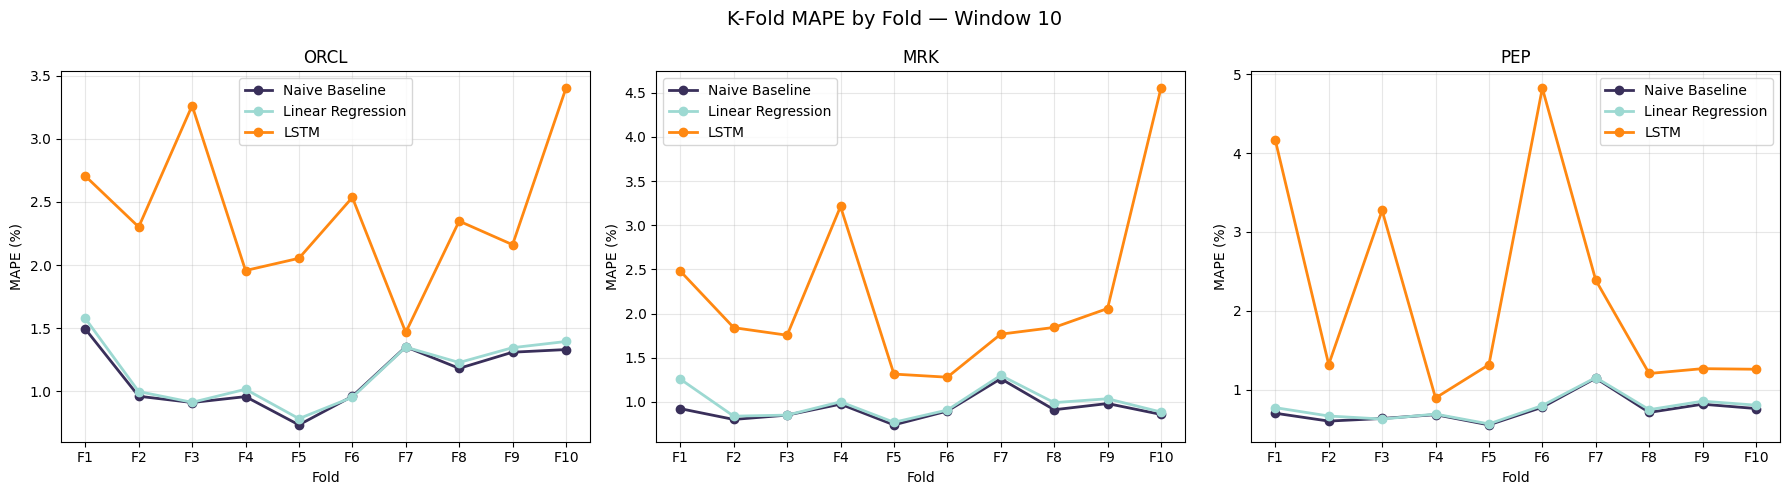

In [81]:
# Fold-by-fold MAPE line chart — individual stocks
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("K-Fold MAPE by Fold — Window 10", fontsize=14)

models = ["Naive Baseline", "Linear Regression", "LSTM"]
colors = ["#392F5A", "#9DD9D2", "#FF8811"]
fold_labels = [f"F{i+1}" for i in range(n_splits)]

for idx, stock in enumerate(target_stocks):
    ax = axes[idx]
    
    for model, color in zip(models, colors):
        mapes = [s[1] for s in kfold_results[stock][model]]
        ax.plot(fold_labels, mapes, marker="o", label=model, color=color, linewidth=2)
    
    ax.set_title(f"{stock}")
    ax.set_xlabel("Fold")
    ax.set_ylabel("MAPE (%)")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("kfold_mape_by_fold.png", dpi=150)
plt.show()

In [ ]:
# Rerun the K-fold loop 3 times with different seeds
n_splits = 10 # number of folds for cross-validation
window = 10 # only testing on 10 day window for this given the performance we saw with the other windows. Would like to see how robust that model is with more data.
n_features = 4
features = ["Adj Close", "Open", "High", "Low"]

tscv = TimeSeriesSplit(n_splits=n_splits)

# need to add a random seed for reproducibility of the LSTM results across folds.
def set_seeds(seed=42):
    np.random.seed(seed)
    random.seed(seed)
    tf.random.set_seed(seed)

SEEDS = [42, 99, 123]

# store all seed results
all_seed_results = {}

for seed in SEEDS:
    print(f"\nRunning K-Fold Cross-Validation with Seed {seed}...")
    set_seeds(seed)

# storing kfold scores
    kfold_results = {
        stock: {
            "Naive Baseline": [],
            "Linear Regression": [],
            "LSTM": []
        } for stock in target_stocks
    }

    for stock in target_stocks:
        print(f"\nStarting Time Series Cross-Validation for {stock}...")
        data = feature_data[stock][["Date"] + features].copy()
        data = data.reset_index(drop=True)
        
        X_raw = data[features].values


        for fold, (train_idx, test_idx) in enumerate(tscv.split(X_raw)):
            print(f"  Fold {fold + 1}/{n_splits} — Train: {len(train_idx)} samples | Test: {len(test_idx)} samples")
            
            train_raw = X_raw[train_idx]  # adjust for window
            test_raw = X_raw[test_idx]    # adjust for window  
            # Fresh Scaler per fold - fit on train only
            fold_scaler = MinMaxScaler()
                
            X_train_scaled = fold_scaler.fit_transform(train_raw)
            X_test_scaled = fold_scaler.transform(test_raw)

            # Recreate sequences with the fold-specific scaled data
            X_train, y_train = create_sequences(X_train_scaled, window)
            X_test, y_test = create_sequences(X_test_scaled, window)


            # inverse transform function for evaluation later
            def inverse_transform_target(scaler, values):
                dummy = np.zeros((len(values), n_features))
                dummy[:, 0] = values
                return scaler.inverse_transform(dummy)[:, 0]
            
            y_test_real = inverse_transform_target(fold_scaler, y_test)

            # Naive Baseline
            y_pred_nb = X_test[:, -1, 0]  # last day in sequence, Adj Close column
            y_pred_nb_real = inverse_transform_target(fold_scaler, y_pred_nb)
            nb_mae = mean_absolute_error(y_test_real, y_pred_nb_real)
            mape_nb = np.mean(np.abs((y_test_real - y_pred_nb_real) / y_test_real)) * 100
            
            kfold_results[stock]["Naive Baseline"].append((nb_mae, mape_nb))

            # Linear Regression
            X_train_lr = X_train.reshape(len(X_train), -1)
            X_test_lr = X_test.reshape(len(X_test), -1)
            lr_model = LinearRegression()
            lr_model.fit(X_train_lr, y_train)
            y_pred_lr = lr_model.predict(X_test_lr)
            y_pred_lr_real = inverse_transform_target(fold_scaler, y_pred_lr)
            lr_mae = mean_absolute_error(y_test_real, y_pred_lr_real)
            mape_lr = np.mean(np.abs((y_test_real - y_pred_lr_real) / y_test_real)) * 100
            kfold_results[stock]["Linear Regression"].append((lr_mae, mape_lr))

            # LSTM
            val_split = int(len(X_train) * 0.8)
            x_tr, y_tr = X_train[:val_split], y_train[:val_split]
            x_val, y_val = X_train[val_split:], y_train[val_split:]
            
            
            # Add Seed logic
            set_seeds(seed)
            tf.keras.backend.clear_session()
            lstm_model = build_lstm_model(window, n_features)
            lstm_model.fit(
                x_tr, y_tr,
                validation_data=(x_val, y_val),
                epochs=100,
                batch_size=8,
                callbacks=[EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)],
                verbose=0
            )
            
            y_pred_lstm = lstm_model.predict(X_test).flatten()
            y_pred_lstm_real = inverse_transform_target(fold_scaler, y_pred_lstm)
            lstm_mae = mean_absolute_error(y_test_real, y_pred_lstm_real)
            mape_lstm = np.mean(np.abs((y_test_real - y_pred_lstm_real) / y_test_real)) * 100
            kfold_results[stock]["LSTM"].append((lstm_mae, mape_lstm))

            print(f"    Naive Baseline — MAE: ${nb_mae:.2f} | MAPE: {mape_nb:.2f}%")
            print(f"    Linear Regression — MAE: ${lr_mae:.2f} | MAPE: {mape_lr:.2f}%")
            print(f"    LSTM — MAE: ${lstm_mae:.2f} | MAPE: {mape_lstm:.2f}%")
# store this seeds results
    all_seed_results[seed] = kfold_results

# Per-Seed Summary
for s in seed:
    print(f"\nSeed {s} Summary:")
    for stock in target_stocks:
        print(f"\n{stock}:")
        for model_name, scores in all_seed_results[s][stock].items():
            mapes = [x[1] for x in scores]
            maes  = [x[0] for x in scores]
            print(f"  {model_name}:")
            print(f"    MAE  — Mean: ${np.mean(maes):.2f} | Std: ${np.std(maes):.2f}")
            print(f"    MAPE — Mean: {np.mean(mapes):.2f}% | Std: {np.std(mapes):.2f}%")


Running K-Fold Cross-Validation with Seed 42...

Starting Time Series Cross-Validation for ORCL...
  Fold 1/10 — Train: 348 samples | Test: 342 samples


C:\Users\Kasual1\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
    Naive Baseline — MAE: $0.36 | MAPE: 1.49%
    Linear Regression — MAE: $0.38 | MAPE: 1.58%
    LSTM — MAE: $0.75 | MAPE: 3.08%
  Fold 2/10 — Train: 690 samples | Test: 342 samples


C:\Users\Kasual1\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
    Naive Baseline — MAE: $0.27 | MAPE: 0.96%
    Linear Regression — MAE: $0.28 | MAPE: 1.00%
    LSTM — MAE: $0.59 | MAPE: 2.08%
  Fold 3/10 — Train: 1032 samples | Test: 342 samples


...

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
    Naive Baseline — MAE: $0.99 | MAPE: 0.71%
    Linear Regression — MAE: $1.03 | MAPE: 0.75%
    LSTM — MAE: $1.57 | MAPE: 1.12%
  Fold 9/10 — Train: 3084 samples | Test: 342 samples


C:\Users\Kasual1\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
    Naive Baseline — MAE: $1.34 | MAPE: 0.81%
    Linear Regression — MAE: $1.40 | MAPE: 0.85%
    LSTM — MAE: $1.80 | MAPE: 1.09%
  Fold 10/10 — Train: 3426 samples | Test: 342 samples


C:\Users\Kasual1\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
    Naive Baseline — MAE: $1.25 | MAPE: 0.76%
    Linear Regression — MAE: $1.32 | MAPE: 0.80%
    LSTM — MAE: $2.63 | MAPE: 1.58%

Seed 42 Summary:

ORCL:
  Naive Baseline:
    MAE  — Mean: $0.64 | Std: $0.46
    MAPE — Mean: 1.12% | Std: 0.23%
  Linear Regression:
    MAE  — Mean: $0.66 | Std: $0.48
    MAPE — Mean: 1.16% | Std: 0.24%
  LSTM:
    MAE  — Mean: $2.41 | Std: $2.20
    MAPE — Mean: 4.00% | Std: 2.21%

MRK:
  Naive Baseline:
    MAE  — Mean: $0.54 | Std: $0.27
    MAPE — Mean: 0.92% | Std: 0.13%
  Linear Regression:
    MAE  — Mean: $0.57 | Std: $0.27
    MAPE — Mean: 0.98% | Std: 0.17%
  LSTM:
    MAE  — Mean: $2.18 | Std: $1.78
    MAPE — Mean: 3.67% | Std: 1.98%

PEP:
  Naive Baseline:
    MAE  — Mean: $0.77 | Std: $0.39
    MAPE — Mean: 0.74% | Std: 0.16%
  Linear Regression:
    MAE  — Mean: $0.80 | Std: $0.41
    MAPE — Mean: 0.77% | Std: 0.15%
  LSTM:
    MAE  — Mean: $4.77 | Std: $3.21
    MAPE — Mean: 4.43% | Std: 1.91%

Se

In [88]:
print(list(all_seed_results.keys()))

# Per-Seed Summary
for s in SEEDS:
    print(f"\nSeed {s} Summary:")
    for stock in target_stocks:
        print(f"\n{stock}:")
        for model_name, scores in all_seed_results[s][stock].items():
            mapes = [x[1] for x in scores]
            maes  = [x[0] for x in scores]
            print(f"  {model_name}:")
            print(f"    MAE  — Mean: ${np.mean(maes):.2f} | Std: ${np.std(maes):.2f}")
            print(f"    MAPE — Mean: {np.mean(mapes):.2f}% | Std: {np.std(mapes):.2f}%")

[42, 99, 123]

Seed 42 Summary:

ORCL:
  Naive Baseline:
    MAE  — Mean: $0.64 | Std: $0.46
    MAPE — Mean: 1.12% | Std: 0.23%
  Linear Regression:
    MAE  — Mean: $0.66 | Std: $0.48
    MAPE — Mean: 1.16% | Std: 0.24%
  LSTM:
    MAE  — Mean: $2.41 | Std: $2.20
    MAPE — Mean: 4.00% | Std: 2.21%

MRK:
  Naive Baseline:
    MAE  — Mean: $0.54 | Std: $0.27
    MAPE — Mean: 0.92% | Std: 0.13%
  Linear Regression:
    MAE  — Mean: $0.57 | Std: $0.27
    MAPE — Mean: 0.98% | Std: 0.17%
  LSTM:
    MAE  — Mean: $2.18 | Std: $1.78
    MAPE — Mean: 3.67% | Std: 1.98%

PEP:
  Naive Baseline:
    MAE  — Mean: $0.77 | Std: $0.39
    MAPE — Mean: 0.74% | Std: 0.16%
  Linear Regression:
    MAE  — Mean: $0.80 | Std: $0.41
    MAPE — Mean: 0.77% | Std: 0.15%
  LSTM:
    MAE  — Mean: $4.77 | Std: $3.21
    MAPE — Mean: 4.43% | Std: 1.91%

Seed 99 Summary:

ORCL:
  Naive Baseline:
    MAE  — Mean: $0.64 | Std: $0.46
    MAPE — Mean: 1.12% | Std: 0.23%
  Linear Regression:
    MAE  — Mean: $0.66 |

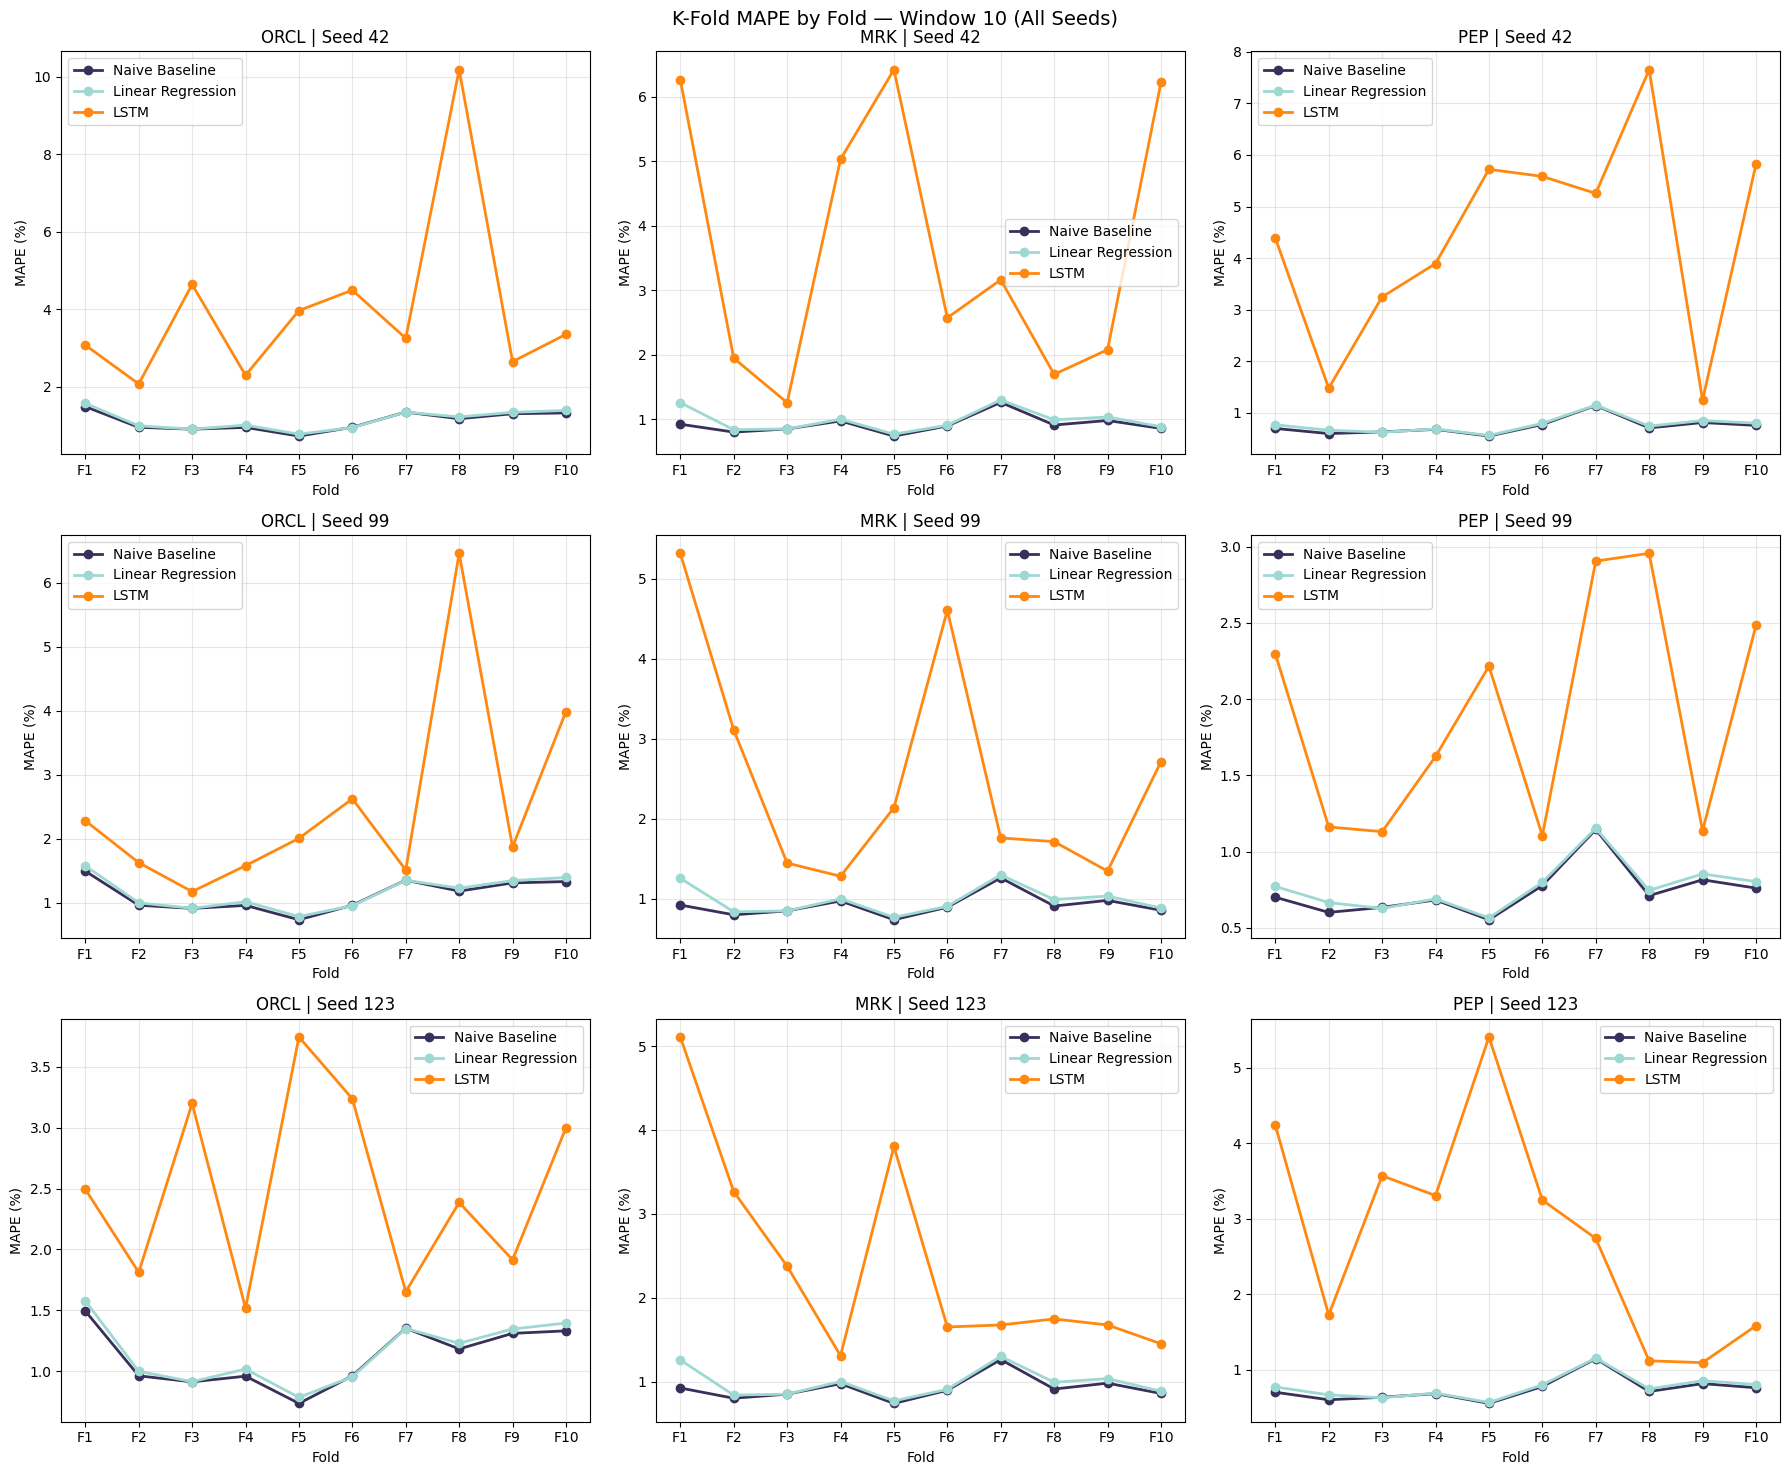

In [93]:
# Fold-by-fold MAPE line chart by seed and stock
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
fig.suptitle("K-Fold MAPE by Fold — Window 10 (All Seeds)", fontsize=14)

models = ["Naive Baseline", "Linear Regression", "LSTM"]
colors = ["#392F5A", "#9DD9D2", "#FF8811"]
fold_labels = [f"F{i+1}" for i in range(n_splits)]

for row, seed in enumerate(SEEDS):
    for col, stock in enumerate(target_stocks):
        ax = axes[row][col]
        
        for model, color in zip(models, colors):
            mapes = [s[1] for s in all_seed_results[seed][stock][model]]
            ax.plot(fold_labels, mapes, marker="o", label=model, color=color, linewidth=2)
        
        ax.set_title(f"{stock} | Seed {seed}")
        ax.set_xlabel("Fold")
        ax.set_ylabel("MAPE (%)")
        ax.legend()
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("kfold_mape_by_seed_and_stock.png", dpi=150)
plt.show()